# Persian Customer Review Intelligence

## End-to-End Persian Sentiment Analysis

This project develops an end-to-end Natural Language Processing system for analyzing Persian customer reviews.

The primary objective is to build a reliable sentiment classification pipeline that can identify the overall sentiment expressed in a Persian review, while following a production-oriented workflow from raw data to model inference and API deployment.

Rather than focusing only on model training, the project covers the complete machine learning lifecycle:

- Data validation and quality assessment
- Exploratory data analysis
- Persian text preprocessing
- Baseline modeling
- Transformer-based modeling
- Model evaluation and comparison
- Error analysis
- Inference pipeline development
- REST API deployment

The project is designed with two priorities in mind: achieving strong predictive performance and maintaining a practical, reproducible, and resource-efficient implementation.

---

## Project Objective

The main objective is to answer the following question:

> Can we build a reliable and efficient NLP system that automatically determines the sentiment of Persian customer reviews?

The final system should be able to receive a Persian review and return a structured prediction containing the predicted sentiment and its confidence score.

---

## Project Scope

The initial task is binary sentiment classification:

- **Positive**
- **Negative**

The project will begin with classical machine learning as a strong baseline and will then evaluate a Persian pretrained Transformer model.

The final model will be selected based on both predictive performance and practical considerations such as inference cost, complexity, and resource requirements.

---

## End-to-End Workflow

The project follows this workflow:

1. Problem Definition
2. Data Loading and Validation
3. Exploratory Data Analysis
4. Persian Text Preprocessing
5. Baseline Modeling
6. Transformer Modeling
7. Model Evaluation
8. Error Analysis
9. Final Model Selection
10. Inference Pipeline
11. FastAPI Deployment
12. Final Documentation

---

## Dataset

The primary dataset used in this project is the SnappFood Persian Sentiment Analysis dataset.

The dataset contains Persian customer reviews labeled according to their overall sentiment.

The dataset will be treated as the primary source for model development and evaluation throughout the project.

##  Environment Setup

Before working with the dataset, we define the core libraries used throughout the data analysis and preprocessing stages.

The imports are intentionally kept limited at this stage. Additional dependencies will be introduced only when they become necessary for a specific modeling or deployment task.

This keeps the environment easier to maintain and reduces unnecessary memory usage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

from pathlib import Path

from datasets import load_dataset
from hazm import Normalizer, word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.neural_network import MLPClassifier

# import transformers
import torch


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


from transformers import AutoTokenizer

import arabic_reshaper
from bidi.algorithm import get_display

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
def reshape_persian_text(text):
    reshaped_text = arabic_reshaper.reshape(str(text))
    return get_display(reshaped_text)

In [3]:
persian_font_path = font_manager.findfont("Tahoma")
persian_font = font_manager.FontProperties(
    fname=persian_font_path
)

##  Reproducibility

Machine learning experiments can produce slightly different results when random operations are involved.

To improve reproducibility, we define a single random seed and reuse it across the project wherever deterministic behavior is applicable.

Keeping this value centralized also makes future experiments easier to reproduce and compare.

In [4]:
RANDOM_STATE = 42

##  Data Loading

The SnappFood dataset has been downloaded locally and is organized into three predefined splits: training, validation, and test data.

Keeping these splits separate allows us to preserve the original dataset structure and maintain a clear distinction between model development and final evaluation.

The training set will be used for model fitting, the validation set for model selection and hyperparameter decisions, and the test set will remain untouched until the final evaluation stage.

Since the dataset is already available locally, no external download is required during the project workflow.

In [ ]:
DATA_DIR = Path(
    r"C:\***\Persian Customer Review Intelligence\data\snappfood"
)

train_path = DATA_DIR / "train.csv"
validation_path = DATA_DIR / "validation.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

## Dataset Structure & Initial Validation

Before performing any preprocessing or exploratory analysis, we first validate the structure and basic integrity of the dataset.

The three predefined splits are inspected independently to verify their dimensions, column names, data types, missing values, and label distributions.

At this stage, no records are modified or removed. The purpose is to understand the raw data and identify potential data quality issues before making any preprocessing decisions.

Keeping this step separate from data cleaning also makes the analysis more transparent and reproducible.

In [6]:
print("Dataset Shapes")
print("-" * 40)

print(f"Train:      {train_df.shape}")
print(f"Validation: {validation_df.shape}")
print(f"Test:       {test_df.shape}")

Dataset Shapes
----------------------------------------
Train:      (52110, 3)
Validation: (8337, 3)
Test:       (9033, 3)


###  Column Structure

The next step is to inspect the columns and data types available in each split.

This allows us to identify the text field, target label, and any auxiliary fields that may be present in the dataset.

Column names will be determined from the actual dataset rather than assumed in advance.

In [7]:
print("Train Columns and Data Types")
print("-" * 40)

print(train_df.dtypes)

print("\nColumn Names")
print("-" * 40)

print(train_df.columns.tolist())

Train Columns and Data Types
----------------------------------------
comment      object
label        object
label_id    float64
dtype: object

Column Names
----------------------------------------
['comment', 'label', 'label_id']


###  Raw Data Preview

A small sample of the raw records is inspected to understand how the data is represented before preprocessing.

Looking at actual examples is particularly important for Persian NLP because issues such as inconsistent spacing, punctuation, Arabic and Persian character variants, emojis, informal language, and mixed-language text cannot be identified reliably from data types alone.

The raw text is kept unchanged at this stage.

In [8]:
display(train_df.head(10))

,comment,label,label_id
0,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,SAD,1.0
1,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,HAPPY,0.0
2,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه....,SAD,1.0
3,با سلام سابق بر این بسته بندی از کیفیت بهتری ب...,SAD,1.0
4,سلام، خیلی ممنون و متشکرم,HAPPY,0.0
5,خیلی زود رسید و ممنون م ازشون,HAPPY,0.0
6,مواد پیتزا بسیااار کم بود با اینکه قیمت اصلا پ...,HAPPY,0.0
7,کیفیت زیاد خوب نبود،,HAPPY,0.0
8,مرغی که واسه ما آوردن بو میداد انگار که مونده ...,SAD,1.0
9,همه چی خوب بود. ولی اگه تخفیف نداشتم اصلا خرید...,HAPPY,0.0


###  Missing Value Analysis

Missing values can affect both preprocessing and model training.

We therefore inspect missing values across all columns before deciding whether any records or fields require special handling.

No missing values are removed automatically at this stage. Any cleaning decision will be based on the role of the affected column and the proportion and nature of the missing data.

In [9]:
missing_summary = pd.DataFrame({
    "train": train_df.isna().sum(),
    "validation": validation_df.isna().sum(),
    "test": test_df.isna().sum(),
})

missing_summary["total"] = missing_summary.sum(axis=1)

missing_summary.sort_values("total", ascending=False)

,train,validation,test,total
comment,0,0,0,0
label,0,0,0,0
label_id,0,0,0,0


###  Duplicate Analysis

Duplicate records can distort the effective size of the training data and may introduce data leakage if identical or near-identical examples appear across different dataset splits.

We first measure exact duplicate rows within each split without modifying the data.

Cross-split duplication will be investigated separately because it requires comparing the relevant fields rather than simply counting duplicated rows inside each DataFrame.

In [10]:
duplicate_summary = pd.Series({
    "train": train_df.duplicated().sum(),
    "validation": validation_df.duplicated().sum(),
    "test": test_df.duplicated().sum(),
})

duplicate_summary

train         0
validation    0
test          0
dtype: int64

###  Label Distribution

Understanding the target distribution is essential before model development.

Class imbalance can influence model training and the interpretation of evaluation metrics. Therefore, we inspect both the absolute number of samples and the relative proportion of each sentiment class in every dataset split.

The original labels are preserved at this stage.

In [11]:
label_counts = pd.DataFrame({
    "train": train_df.iloc[:, -1].value_counts(),
    "validation": validation_df.iloc[:, -1].value_counts(),
    "test": test_df.iloc[:, -1].value_counts(),
}).fillna(0).astype(int)

label_counts

,train,validation,test
label_id,,,
0.0,26236,4194,4486
1.0,25874,4143,4547


##  Exploratory Data Analysis

Before applying any preprocessing or training machine learning models, we first explore the characteristics of the dataset.

The goal of this stage is to understand the distribution of sentiment labels, the structure of the review texts, and potential data quality issues that may affect downstream modeling.

The analysis focuses on:

* Sentiment distribution across dataset splits
* Review length in characters and words
* Very short or empty reviews
* Differences in text length across sentiment classes
* General characteristics of Persian customer reviews

No text transformation is performed during this stage. The raw dataset is kept unchanged while we investigate its characteristics.

###  Visualization Configuration

To maintain a consistent visual style throughout the project, plotting parameters are defined centrally before creating the EDA visualizations.

A shared configuration helps keep the figures visually consistent in terms of typography, spacing, figure size, grid appearance, and overall readability.

This also avoids repeating the same styling parameters across individual plots.

In [12]:
def set_plot_style():
    """Apply the shared visualization style used throughout the project."""

    plt.rcParams.update({
        "figure.figsize": (10, 6),
        "figure.dpi": 100,
        "savefig.dpi": 300,

        "font.family": "Times New Roman",
        "font.size": 12,

        "axes.titlesize": 16,
        "axes.titleweight": "bold",

        "axes.labelsize": 13,
        "axes.labelweight": "bold",

        "xtick.labelsize": 11,
        "ytick.labelsize": 11,

        "legend.fontsize": 11,
        "legend.title_fontsize": 11,

        "axes.grid": True,
        "grid.alpha": 0.25,

        "axes.spines.top": False,
        "axes.spines.right": False,

        "figure.autolayout": False,
    })

    sns.set_context("notebook")


set_plot_style()

PRIMARY_COLOR = "#06B4F8FF"
SECONDARY_COLOR = "#F8067FEF"


In [13]:
label_distribution = pd.DataFrame({
    "train": train_df.iloc[:, -1].value_counts(normalize=True),
    "validation": validation_df.iloc[:, -1].value_counts(normalize=True),
    "test": test_df.iloc[:, -1].value_counts(normalize=True),
}).fillna(0)

label_distribution

,train,validation,test
label_id,,,
0.0,0.503473,0.503059,0.496623
1.0,0.496527,0.496941,0.503377


In [14]:
label_distribution = label_counts.div(label_counts.sum(axis=0), axis=1) * 100

label_distribution.round(2)

,train,validation,test
label_id,,,
0.0,50.35,50.31,49.66
1.0,49.65,49.69,50.34


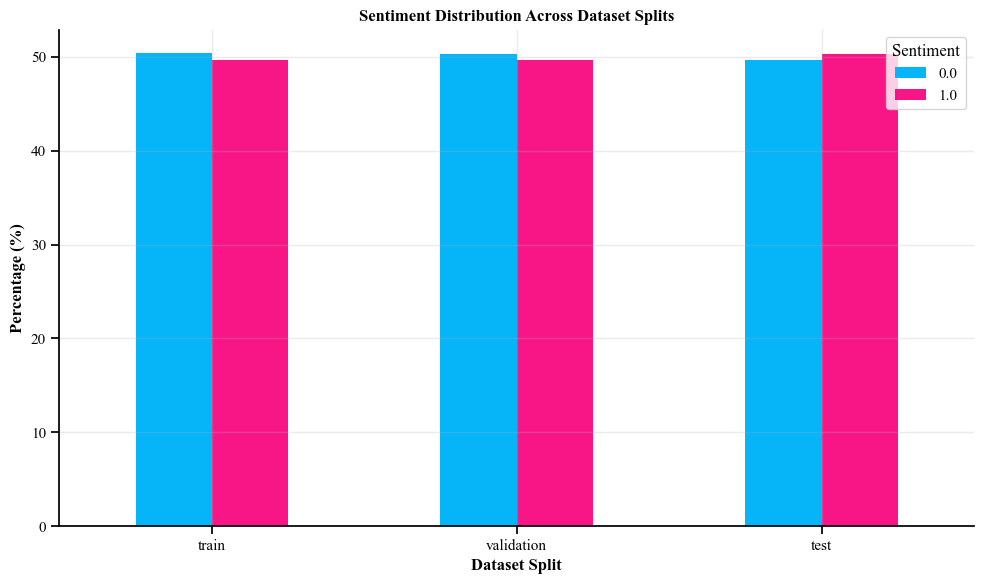

In [15]:
label_distribution.T.plot(
    kind="bar",
    figsize=(10, 6),
    color=[PRIMARY_COLOR, SECONDARY_COLOR]
)

plt.title("Sentiment Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

### Dataset Split Overview

The dataset contains three predefined splits: training, validation, and test.

Before analyzing the text itself, we examine the relative size of each split to understand how the available samples are distributed across the modeling workflow.

The training set is used for model fitting, the validation set supports model selection and tuning, and the test set is reserved for the final evaluation.


In [16]:
split_counts = pd.Series({
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df),
})

split_percentages = (
    split_counts
    .div(split_counts.sum())
    .mul(100)
    .round(2)
)

split_summary = pd.DataFrame({
    "Samples": split_counts,
    "Percentage": split_percentages,
})

split_summary

,Samples,Percentage
Train,52110,75.0
Validation,8337,12.0
Test,9033,13.0


In [17]:
print("Dataset Columns")
print("-" * 40)

for column in train_df.columns:
    print(f"{column:<20} | {train_df[column].dtype}")

Dataset Columns
----------------------------------------
comment              | object
label                | object
label_id             | float64


###  Column Configuration

Based on the dataset schema, the review text is stored in the `comment` column, while `label` contains the sentiment label.

The `label_id` column is a numeric representation associated with the labels and will be inspected separately before deciding whether it is required for modeling.

The column names are defined explicitly to avoid hard-coding them throughout the notebook.


In [18]:
TEXT_COLUMN = "comment"
TARGET_COLUMN = "label"
LABEL_ID_COLUMN = "label_id"

###  Label Inspection

The target labels are inspected before modeling to verify their actual values and their relationship with the numeric label identifiers.

This step ensures that the target representation is understood correctly before preprocessing and model training.

In [19]:
print("Label Values")
print("-" * 40)

print(train_df[TARGET_COLUMN].value_counts(dropna=False))

print("\nLabel ID Values")
print("-" * 40)

print(train_df[LABEL_ID_COLUMN].value_counts(dropna=False).sort_index())

Label Values
----------------------------------------
label
HAPPY    26236
SAD      25874
Name: count, dtype: int64

Label ID Values
----------------------------------------
label_id
0.0    26236
1.0    25874
Name: count, dtype: int64


In [20]:
label_mapping_check = (
    train_df[[TARGET_COLUMN, LABEL_ID_COLUMN]]
    .drop_duplicates()
    .sort_values([TARGET_COLUMN, LABEL_ID_COLUMN])
)

label_mapping_check

,label,label_id
1,HAPPY,0.0
0,SAD,1.0


###  Raw Review Inspection

Before applying any text preprocessing, we inspect representative examples from the original reviews.

This is particularly important for Persian customer-generated text because reviews may contain informal language, inconsistent spacing, punctuation, emojis, repeated characters, and different forms of Persian and Arabic characters.

The purpose of this step is to understand the raw text characteristics before deciding which normalization and preprocessing operations are appropriate.

In [21]:
sample_reviews = (
    train_df[[TEXT_COLUMN, TARGET_COLUMN]]
    .sample(10, random_state=RANDOM_STATE)
)

display(sample_reviews)

,comment,label
50874,راضی بودم از نان‌ها، همانطور که گفته بودم، برش...,HAPPY
29871,چلو جوجه خیلی خوب بود جوجه آبدار برنج خوش عطر ...,HAPPY
27389,سالاد سزار و نان سیر عالی بودن,HAPPY
34734,مواد پیتزا کم بود,HAPPY
4119,قیمت موز ۳ برابر بود و تعداد و وزن بسیار کم!!!!,HAPPY
26394,سلام غذا در زمان مناسب و گرم آورده شد بسته بند...,HAPPY
31520,واقعا افتضاح بود اصلا ارزش نداشت,SAD
26184,سلام. هیچ فرقی با بقیه جاها نداره یجوری زدید ب...,SAD
36371,نصف سفارشاتی که داده بودم داخل بسته بندی نبود!...,SAD
46404,فقط بنویسن نون پیتزا چون چیز دیگه‌ای نداشت,SAD


###  Raw Text Quality Analysis

A small random sample provides only a qualitative view of the reviews and is not sufficient to identify systematic text patterns.

Therefore, we now analyze the complete training set using measurable text-quality indicators.

The analysis focuses on characteristics that may influence Persian text preprocessing, including:

* Missing or empty reviews
* Whitespace-only reviews
* Review length
* Extremely short reviews
* Presence of English characters
* Presence of digits
* Presence of URLs
* Presence of emojis

These checks are performed on the raw text without modifying the original reviews.

In [22]:
missing_reviews = train_df[TEXT_COLUMN].isna().sum()

empty_reviews = (
    train_df[TEXT_COLUMN]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Text Quality Summary")
print("-" * 40)
print(f"Missing reviews: {missing_reviews:,}")
print(f"Empty reviews:   {empty_reviews:,}")

Text Quality Summary
----------------------------------------
Missing reviews: 0
Empty reviews:   0


In [23]:
eda_df = train_df[[TEXT_COLUMN, TARGET_COLUMN]].copy()

eda_df["character_count"] = (
    eda_df[TEXT_COLUMN]
    .fillna("")
    .str.len()
)

eda_df["word_count"] = (
    eda_df[TEXT_COLUMN]
    .fillna("")
    .str.split()
    .str.len()
)

eda_df.head()

,comment,label,character_count,word_count
0,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,SAD,48,11
1,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,HAPPY,46,9
2,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه....,SAD,111,21
3,با سلام سابق بر این بسته بندی از کیفیت بهتری ب...,SAD,199,40
4,سلام، خیلی ممنون و متشکرم,HAPPY,25,5


In [24]:
length_summary = (
    eda_df[["character_count", "word_count"]]
    .describe()
    .round(2)
)

length_summary

,character_count,word_count
count,52110.00,52110.00
mean,89.89,18.67
std,77.25,15.92
min,11.00,4.00
25%,39.00,8.00
50%,66.00,14.00
75%,114.00,24.00
max,1700.00,361.00


In [25]:
length_by_sentiment = (
    eda_df
    .groupby(TARGET_COLUMN)[["character_count", "word_count"]]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

length_by_sentiment

character_count                          word_count                    \
                count    mean median min   max      count   mean median min   
label                                                                         
HAPPY           26236   76.88   56.0  12   846      26236  15.99   12.0   4   
SAD             25874  103.09   79.0  11  1700      25874  21.39   16.0   4   

            
       max  
label       
HAPPY  180  
SAD    361

###  Raw Text Pattern Analysis

Persian customer reviews may contain a mixture of Persian and non-Persian characters, digits, URLs, emojis, and other textual patterns.

Instead of relying on a small sample, these characteristics are measured across the complete training set.

The purpose of this analysis is to determine which normalization and preprocessing operations are actually justified by the data.

In [26]:
import re

text_series = train_df[TEXT_COLUMN].fillna("")

pattern_counts = {
    "Contains English characters": text_series.str.contains(
        r"[A-Za-z]", regex=True
    ).sum(),

    "Contains digits": text_series.str.contains(
        r"[0-9۰-۹]", regex=True
    ).sum(),

    "Contains URL": text_series.str.contains(
        r"(https?://|www\.)\S+",
        regex=True
    ).sum(),

    "Contains ZWNJ": text_series.str.contains(
        "\u200c",
        regex=False
    ).sum(),

    "Contains Tatweel": text_series.str.contains(
        "\u0640",
        regex=False
    ).sum(),

    "Contains Arabic character variants": text_series.str.contains(
        r"[يىك]",
        regex=True
    ).sum(),
}

pattern_summary = pd.Series(pattern_counts, name="Review Count")

pattern_summary

C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\1207112478.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Contains URL": text_series.str.contains(


Contains English characters             276
Contains digits                        4297
Contains URL                              0
Contains ZWNJ                         12093
Contains Tatweel                          0
Contains Arabic character variants      788
Name: Review Count, dtype: int64

###  Emoji and Repeated Character Analysis

Customer reviews may contain emojis and repeated characters used to express emphasis or emotion.

Because these patterns can carry sentiment-related information, they should not be removed automatically.

Instead, their frequency is measured across the complete training set before making any preprocessing decision.

In [27]:
emoji_pattern = r"[\U0001F300-\U0001FAFF\u2600-\u27BF]"

repeated_char_pattern = r"(\S)\1{2,}"

emoji_count = text_series.str.contains(
    emoji_pattern,
    regex=True
).sum()

repeated_character_count = text_series.str.contains(
    repeated_char_pattern,
    regex=True
).sum()

pattern_summary_extended = pd.Series({
    "Contains emoji": emoji_count,
    "Contains repeated characters": repeated_character_count,
}, name="Review Count")

pattern_summary_extended

C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\3745697674.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_character_count = text_series.str.contains(


Contains emoji                     0
Contains repeated characters    3579
Name: Review Count, dtype: int64

###  Review Length Distribution

The statistical summary showed that review lengths vary considerably across the training data.

The median review contains 66 characters and 14 words, while the maximum values reach 1,700 characters and 361 words.

To better understand this variation and identify potential long-text outliers, the distribution of character and word counts is visualized.

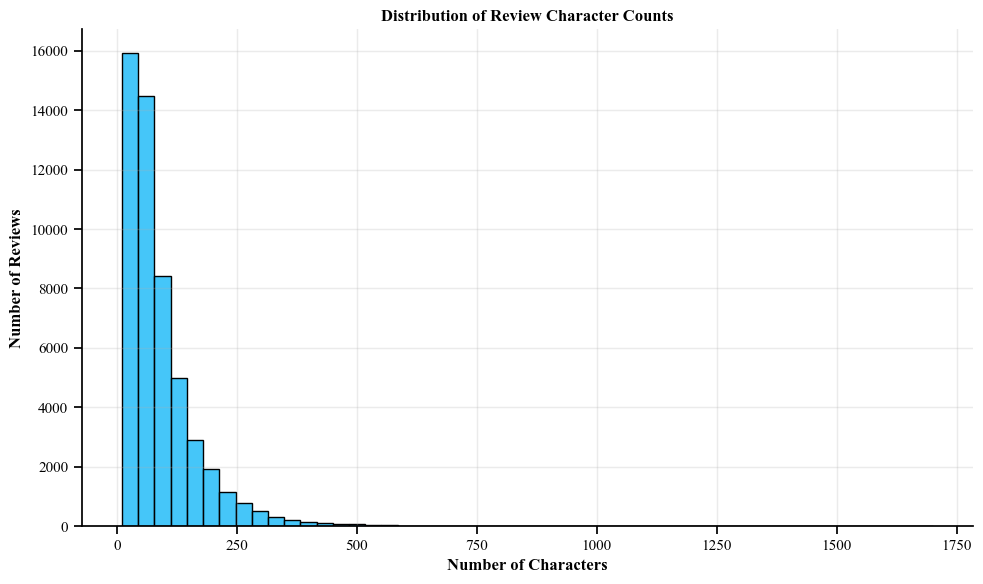

In [28]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="character_count",
    bins=50,
    color= PRIMARY_COLOR
)

plt.title("Distribution of Review Character Counts")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

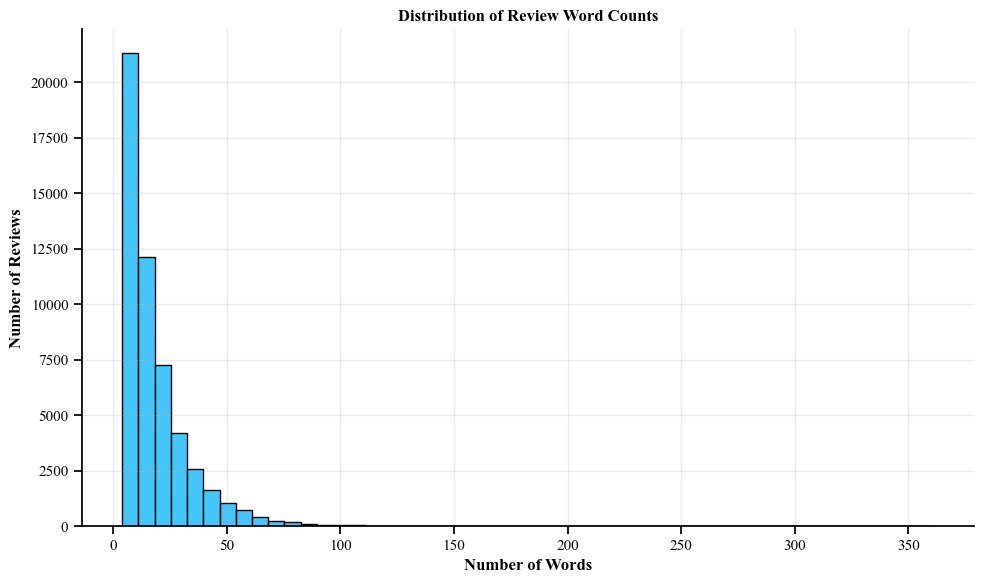

In [29]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="word_count",
    bins=50,
    color= PRIMARY_COLOR
)

plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


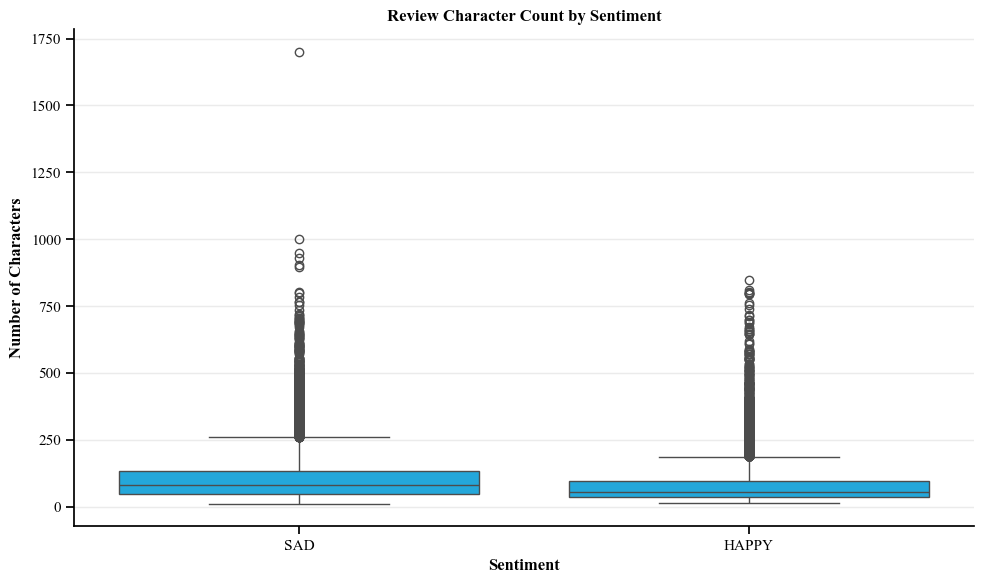

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x=TARGET_COLUMN,
    y="character_count",
    color= PRIMARY_COLOR
)

plt.title("Review Character Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Characters")

plt.tight_layout()
plt.show()

###  Review Length Percentiles

The distributions show a long right tail, with a relatively small number of substantially longer reviews.

To quantify this behavior, we examine several percentiles of the character and word count distributions.

Percentiles provide a more robust view of typical review lengths than the maximum value alone and help distinguish the main body of the data from extreme observations.

In [31]:
length_percentiles = (
    eda_df[["character_count", "word_count"]]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
    .rename(index={
        0.50: "50th percentile",
        0.75: "75th percentile",
        0.90: "90th percentile",
        0.95: "95th percentile",
        0.99: "99th percentile",
        1.00: "100th percentile",
    })
    .round(2)
)

length_percentiles

,character_count,word_count
50th percentile,66.0,14.0
75th percentile,114.0,24.0
90th percentile,182.0,38.0
95th percentile,237.0,49.0
99th percentile,382.0,79.0
100th percentile,1700.0,361.0


###  Repeated Character Analysis

The raw text analysis identified repeated-character patterns in a subset of the reviews.

Repeated characters can occur naturally in customer-generated Persian text and may be used to emphasize emotions or opinions. Therefore, they should not be automatically treated as noise.

We first inspect representative examples and compare their frequency across sentiment classes before deciding whether normalization is appropriate.

In [32]:
repeated_mask = text_series.str.contains(
    repeated_char_pattern,
    regex=True
)

repeated_reviews = (
    train_df.loc[
        repeated_mask,
        [TEXT_COLUMN, TARGET_COLUMN]
    ]
    .sample(
        20,
        random_state=RANDOM_STATE
    )
)

display(repeated_reviews)

C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\1151333578.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_mask = text_series.str.contains(


,comment,label
13242,غذا خیلی خیلی زود به دستمون رسید و حجم غذا زیا...,HAPPY
38938,ممنونم بابت تخفیفات خوبتون و اینکه یه خوشبوکنن...,HAPPY
20418,خیلییییی خوب بود غذا کیفیتش عاااالی بود مزه و ...,HAPPY
7911,تخم مرغ یک عدد شکسته بود و خیلی کثیف!!!,SAD
21355,فیله استریپس که مثل همیشه عااالی. برگر کانادای...,HAPPY
32498,قیمت روغن رو پاک کردن. از قسمت پاک شده مشخصه ر...,SAD
1830,برای بنده نوشابه قوطی آورده نشد و گفته شد در ر...,SAD
48850,متاسفانه من شیر کم لاکتوز دامداران خواسته بودم...,HAPPY
13419,سلام؛ من تا حالا ۳ بار به رستوران راد سفارش دا...,SAD
44903,عالی بود گوشت کوبشم خوب بود:)))),HAPPY


In [33]:
repeated_by_sentiment = (
    train_df.assign(
        has_repeated_characters=repeated_mask
    )
    .groupby(TARGET_COLUMN)["has_repeated_characters"]
    .agg(["sum", "mean"])
)

repeated_by_sentiment["percentage"] = (
    repeated_by_sentiment["mean"] * 100
).round(2)

repeated_by_sentiment = repeated_by_sentiment.drop(
    columns="mean"
)

repeated_by_sentiment

,sum,percentage
label,,
HAPPY,1501,5.72
SAD,2078,8.03


###  Duplicate Review Analysis

Duplicate reviews require special attention in sentiment classification because identical text appearing in different dataset splits can lead to data leakage.

An exact duplicate within a single split affects the effective dataset size, while a duplicate appearing across training, validation, and test sets is more critical because the model may encounter the same text during training and evaluation.

Therefore, cross-split duplicate reviews are explicitly checked before model development.

In [34]:
train_comments = set(train_df[TEXT_COLUMN].dropna())
validation_comments = set(validation_df[TEXT_COLUMN].dropna())
test_comments = set(test_df[TEXT_COLUMN].dropna())

train_validation_overlap = train_comments & validation_comments
train_test_overlap = train_comments & test_comments
validation_test_overlap = validation_comments & test_comments

cross_split_duplicates = pd.Series({
    "Train ↔ Validation": len(train_validation_overlap),
    "Train ↔ Test": len(train_test_overlap),
    "Validation ↔ Test": len(validation_test_overlap),
})

cross_split_duplicates

Train ↔ Validation    0
Train ↔ Test          0
Validation ↔ Test     0
dtype: int64

In [35]:
if train_validation_overlap:
    print("Train ↔ Validation examples:")
    print(list(train_validation_overlap)[:10])

if train_test_overlap:
    print("\nTrain ↔ Test examples:")
    print(list(train_test_overlap)[:10])

if validation_test_overlap:
    print("\nValidation ↔ Test examples:")
    print(list(validation_test_overlap)[:10])

### 6.14 Very Short Review Analysis

Extremely short texts can be problematic in sentiment classification because they may contain insufficient linguistic information for reliable prediction.

The dataset statistics already indicate that the minimum review length is four words, but we further inspect the shortest reviews to verify that they contain meaningful text rather than malformed or incomplete records.

In [36]:
shortest_reviews = (
    eda_df
    .sort_values(
        ["word_count", "character_count"]
    )
    [[TEXT_COLUMN, TARGET_COLUMN, "word_count", "character_count"]]
    .head(20)
)

display(shortest_reviews)

,comment,label,word_count,character_count
41950,خوب و ب موقع,HAPPY,4,12
44190,خوب و سر وقت,HAPPY,4,12
48412,غذا سرد و بد,SAD,4,12
6263,نون یخ یخ بود,HAPPY,4,13
6867,خوش طعم و داغ,HAPPY,4,13
9281,یه کم ترش بود,HAPPY,4,13
10836,عالی و با ادب,HAPPY,4,13
12617,نصفش کف بود …,SAD,4,13
16364,خوب و خوش مزه,HAPPY,4,13
16422,هر دو سرد بود,HAPPY,4,13


###  Exploratory Data Analysis Summary

The exploratory analysis provided several important insights into the structure and quality of the SnappFood review data.

The dataset contains no missing or empty reviews, and no exact duplicate reviews were found across the predefined train, validation, and test splits.

The sentiment classes are also well balanced, with approximately half of the training samples belonging to each class.

Review lengths are strongly right-skewed. Most reviews are relatively short, while a small number of substantially longer reviews form a long tail. These long reviews are considered valid observations and will not be removed solely because of their length.

Several text-specific patterns were identified:

* Arabic character variants are present and require normalization.
* Zero-width non-joiners are common and require careful handling.
* Digits appear in a meaningful portion of the reviews and will be preserved.
* English characters occur in a small number of reviews and will not be removed automatically.
* URLs, emojis, and Tatweel characters were not observed in the training data.
* Repeated characters occur in a subset of reviews and are more common in SAD reviews, so they will not be removed without further justification.

These findings will guide the design of the Persian text preprocessing pipeline in the next stage.

###  Final Data Quality Check

Before moving to text preprocessing, a final structural check is performed to confirm that the three dataset splits remain intact and that no preprocessing or cleaning operation has modified the raw data.

This provides a clear checkpoint between raw-data exploration and the preprocessing stage.

In [37]:
final_data_check = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "columns": [
        train_df.shape[1],
        validation_df.shape[1],
        test_df.shape[1],
    ],
    "missing_comments": [
        train_df[TEXT_COLUMN].isna().sum(),
        validation_df[TEXT_COLUMN].isna().sum(),
        test_df[TEXT_COLUMN].isna().sum(),
    ],
})

final_data_check

,split,rows,columns,missing_comments
0,train,52110,3,0
1,validation,8337,3,0
2,test,9033,3,0


##  Persian Text Preprocessing

Persian text requires careful normalization because user-generated reviews may contain multiple Unicode representations, inconsistent spacing, and informal writing patterns.

The preprocessing pipeline will therefore focus on normalization steps that are supported by the characteristics observed during exploratory analysis.

The objective is not to aggressively clean the text. Instead, the goal is to reduce representational inconsistencies while preserving information that may contribute to sentiment prediction.

The preprocessing pipeline will be applied consistently across the training, validation, and test datasets.

###  Preprocessing Strategy

Based on the exploratory analysis, preprocessing will focus on the following operations:

1. Persian and Arabic character normalization
2. Whitespace normalization
3. Preservation of meaningful digits
4. Preservation of English text
5. Preservation of repeated characters
6. Removal of unnecessary surrounding whitespace

Operations such as URL removal, emoji removal, and Tatweel removal are not included because these patterns were not observed in the current dataset.

The preprocessing pipeline will be implemented as a reusable function so that exactly the same transformations can be applied during training and inference.

In [38]:
normalizer = Normalizer(
    correct_spacing=True,
    remove_diacritics=True,
    remove_specials_chars=True,
    decrease_repeated_chars=False,
    persian_style=True,
    persian_numbers=False,
    unicodes_replacement=True,
    seperate_mi=True,
)

In [39]:
normalization_preview = (
    train_df[[TEXT_COLUMN]]
    .sample(10, random_state=RANDOM_STATE)
    .copy()
)

normalization_preview["normalized_text"] = (
    normalization_preview[TEXT_COLUMN]
    .apply(normalizer.normalize)
)

display(normalization_preview)

,comment,normalized_text
50874,راضی بودم از نان‌ها، همانطور که گفته بودم، برش...,راضی بودم از نان‌ها، همانطور که گفته بودم، برش...
29871,چلو جوجه خیلی خوب بود جوجه آبدار برنج خوش عطر ...,چلو جوجه خیلی خوب بود جوجه آبدار برنج خوش عطر ...
27389,سالاد سزار و نان سیر عالی بودن,سالاد سزار و نان سیر عالی بودن
34734,مواد پیتزا کم بود,مواد پیتزا کم بود
4119,قیمت موز ۳ برابر بود و تعداد و وزن بسیار کم!!!!,قیمت موز ۳ برابر بود و تعداد و وزن بسیار کم!!!!
26394,سلام غذا در زمان مناسب و گرم آورده شد بسته بند...,سلام غذا در زمان مناسب و گرم آورده شد بسته بند...
31520,واقعا افتضاح بود اصلا ارزش نداشت,واقعا افتضاح بود اصلا ارزش نداشت
26184,سلام. هیچ فرقی با بقیه جاها نداره یجوری زدید ب...,سلام. هیچ فرقی با بقیه جاها نداره یجوری زدید ب...
36371,نصف سفارشاتی که داده بودم داخل بسته بندی نبود!...,نصف سفارشاتی که داده بودم داخل بسته بندی نبود!...
46404,فقط بنویسن نون پیتزا چون چیز دیگه‌ای نداشت,فقط بنویسن نون پیتزا چون چیز دیگه‌ای نداشت


###  Normalization Validation

A small before-and-after sample provides a qualitative inspection of the normalization process, but it is not sufficient to validate the transformation across the complete dataset.

Therefore, the normalization process is evaluated quantitatively on the full training set.

The validation focuses on three aspects:

* How many reviews were actually modified
* Whether normalization reduces Arabic character variants
* Whether the number of reviews containing ZWNJ changes unexpectedly

The original raw text remains unchanged throughout this validation step.

In [40]:
normalized_text = train_df[TEXT_COLUMN].fillna("").apply(
    normalizer.normalize
)

normalization_changed = (
    train_df[TEXT_COLUMN].fillna("") != normalized_text
)

normalization_summary = pd.Series({
    "Total reviews": len(train_df),
    "Changed reviews": normalization_changed.sum(),
    "Unchanged reviews": (~normalization_changed).sum(),
    "Changed percentage": normalization_changed.mean() * 100,
}).round(2)

normalization_summary

Total reviews         52110.00
Changed reviews       18071.00
Unchanged reviews     34039.00
Changed percentage       34.68
dtype: float64

In [41]:
arabic_variant_pattern = r"[يىك]"
zwnj_pattern = "\u200c"

before_arabic_variants = train_df[TEXT_COLUMN].fillna("").str.contains(
    arabic_variant_pattern,
    regex=True
).sum()

after_arabic_variants = normalized_text.str.contains(
    arabic_variant_pattern,
    regex=True
).sum()

before_zwnj = train_df[TEXT_COLUMN].fillna("").str.contains(
    zwnj_pattern,
    regex=False
).sum()

after_zwnj = normalized_text.str.contains(
    zwnj_pattern,
    regex=False
).sum()

normalization_character_check = pd.DataFrame({
    "Before": [
        before_arabic_variants,
        before_zwnj,
    ],
    "After": [
        after_arabic_variants,
        after_zwnj,
    ],
}, index=[
    "Arabic character variants",
    "ZWNJ",
])

normalization_character_check

,Before,After
Arabic character variants,788,0
ZWNJ,12093,23576


In [ ]:
zwnj_pattern = "\u200c"

before_zwnj = train_df[TEXT_COLUMN].fillna("").str.contains(
    zwnj_pattern,
    regex=False
).sum()

after_zwnj = normalized_text.str.contains(
    zwnj_pattern,
    regex=False
).sum()

zwnj_check = pd.Series({
    "Before normalization": before_zwnj,
    "After normalization": after_zwnj,
    "Difference": after_zwnj - before_zwnj,
})

zwnj_check

Before normalization    12093
After normalization     23576
Difference              11483
dtype: int64

###  Revised Normalizer Configuration

The initial normalization validation revealed that the default configuration of the normalizer performs transformations that are not fully aligned with the preprocessing decisions derived from the exploratory analysis.

In particular, repeated-character reduction and number conversion are enabled by default.

Because repeated characters may contain sentiment-related information and digits are present in a meaningful portion of the dataset, these transformations are disabled.

Other normalization operations, such as Unicode normalization and Persian spacing correction, are retained.

In [43]:
repeated_before = train_df[TEXT_COLUMN].fillna("").str.contains(
    repeated_char_pattern,
    regex=True
).sum()

repeated_after = normalized_text.str.contains(
    repeated_char_pattern,
    regex=True
).sum()

repeated_character_check = pd.Series({
    "Before normalization": repeated_before,
    "After normalization": repeated_after,
    "Difference": repeated_after - repeated_before,
})

repeated_character_check

C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\3678096596.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_before = train_df[TEXT_COLUMN].fillna("").str.contains(
C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\3678096596.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_after = normalized_text.str.contains(


Before normalization    3579
After normalization     3578
Difference                -1
dtype: int64

In [44]:
digit_pattern = r"[0-9۰-۹]"

digits_before = train_df[TEXT_COLUMN].fillna("").str.contains(
    digit_pattern,
    regex=True
).sum()

digits_after = normalized_text.str.contains(
    digit_pattern,
    regex=True
).sum()

digit_check = pd.Series({
    "Before normalization": digits_before,
    "After normalization": digits_after,
    "Difference": digits_after - digits_before,
})

digit_check

Before normalization    4297
After normalization     4297
Difference                 0
dtype: int64

In [45]:
empty_after_normalization = (
    normalized_text.str.strip().eq("").sum()
)

print(
    "Empty reviews after normalization:",
    empty_after_normalization
)

Empty reviews after normalization: 0


In [46]:
normalization_examples = pd.DataFrame({
    "Original": train_df.loc[normalization_changed, TEXT_COLUMN].head(10).values,
    "Normalized": normalized_text.loc[normalization_changed].head(10).values
})

normalization_examples

,Original,Normalized
0,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه....,غذا بد بود حالم خیییییلی بده. دل دردو دل‌پیچه....
1,با سلام سابق بر این بسته بندی از کیفیت بهتری ب...,با سلام سابق بر این بسته بندی از کیفیت بهتری ب...
2,خیلی زود رسید و ممنون م ازشون,خیلی زود رسید و ممنون‌م ازشون
3,مرغی که واسه ما آوردن بو میداد انگار که مونده ...,مرغی که واسه ما آوردن بو می‌داد انگار که مونده...
4,غذا بسیار لذیذ با طعمی فوق العاده بود جوجه بسی...,غذا بسیار لذیذ با طعمی فوق‌العاده بود جوجه بسی...
5,کیفیت پایین‌تر از پایین، در حد یه ساندویچ ۸-۹ ...,کیفیت پایین‌تر از پایین، در حد یه ساندویچ ۸ - ...
6,هم سفارش زود رسید به دستمون هم غذاها واقعا خوش...,هم سفارش زود رسید به دستمون هم غذاها واقعا خوش...
7,بلک فارست هیچ شباهت ظاهری با تصویر موجود در من...,بلک فارست هیچ شباهت ظاهری با تصویر موجود در من...
8,خوب بود فقط خیلی بی نمک بود و ادویه نداشت,خوب بود فقط خیلی بی‌نمک بود و ادویه نداشت
9,کوکتل آرژانتینی بخاطر آب پز بودن خیلی دوست داشتم,کوکتل آرژانتینی بخاطر آب‌پز بودن خیلی دوست داشتم


In [47]:
for index, row in normalization_examples.iterrows():
    print(f"Example {index + 1}")
    print("Original:")
    print(row["Original"])
    print("\nNormalized:")
    print(row["Normalized"])
    print("-" * 100)

Example 1
Original:
غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.

Normalized:
غذا بد بود حالم خیییییلی بده. دل دردو دل‌پیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.
----------------------------------------------------------------------------------------------------
Example 2
Original:
با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود. ولی در حال حاضر ایراداتی وجود داره. به طور نمونه نوشابه قوطی فاقد نی هست، چنگال برای سرو سیب زمینی نداره، دستمال کاغذی هم در بسته بندی نیست.

Normalized:
با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود. ولی در حال حاضر ایراداتی وجود داره. به طور نمونه نوشابه قوطی فاقد نی هست، چنگال برای سرو سیب‌زمینی نداره، دستمال کاغذی هم در بسته بندی نیست.
----------------------------------------------------------------------------------------------------
Example 3
Original:
خیلی زود رسید و ممنون م ازشون

Normalized:
خیلی زود رسید و ممنون‌م ازشون
---------------

### Build a Reusable Persian Text Preprocessing Function

To ensure consistent text processing across training, evaluation, and inference, the normalization logic is encapsulated in a reusable preprocessing function.

The function is intentionally conservative: it standardizes Persian text and spacing while preserving potentially informative features such as repeated characters and numeric expressions.

In [48]:
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = normalizer.normalize(text)
    
    return text.strip()

In [49]:
sample_texts = [
    "غذا بد بود حالم خیییییلی بده.",
    "خیلی زود رسید و ممنون م ازشون",
    "هم سفارش زود رسید به دستمون",
    "کیفیت پایین‌تر از پایین، در حد یه ساندویچ ۸-۹ تومنی بود!"
]

for text in sample_texts:
    print("Original:")
    print(text)
    print("\nProcessed:")
    print(preprocess_text(text))
    print("-" * 100)

Original:
غذا بد بود حالم خیییییلی بده.

Processed:
غذا بد بود حالم خیییییلی بده.
----------------------------------------------------------------------------------------------------
Original:
خیلی زود رسید و ممنون م ازشون

Processed:
خیلی زود رسید و ممنون‌م ازشون
----------------------------------------------------------------------------------------------------
Original:
هم سفارش زود رسید به دستمون

Processed:
هم سفارش زود رسید به دستمون
----------------------------------------------------------------------------------------------------
Original:
کیفیت پایین‌تر از پایین، در حد یه ساندویچ ۸-۹ تومنی بود!

Processed:
کیفیت پایین‌تر از پایین، در حد یه ساندویچ ۸ - ۹ تومنی بود!
----------------------------------------------------------------------------------------------------


###  Apply Preprocessing to All Dataset Splits

The validated preprocessing function is now applied consistently to the training, validation, and test sets.

The original review text is preserved in the `comment` column, while the processed version is stored separately in `processed_comment`. This allows the raw text to remain available for later error analysis and qualitative inspection.

In [50]:
train_df["processed_comment"] = train_df[TEXT_COLUMN].apply(
    preprocess_text
)

validation_df["processed_comment"] = validation_df[TEXT_COLUMN].apply(
    preprocess_text
)

test_df["processed_comment"] = test_df[TEXT_COLUMN].apply(
    preprocess_text
)

In [51]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "Raw Text Missing": [
        train_df[TEXT_COLUMN].isna().sum(),
        validation_df[TEXT_COLUMN].isna().sum(),
        test_df[TEXT_COLUMN].isna().sum(),
    ],
    "Processed Text Missing": [
        train_df["processed_comment"].isna().sum(),
        validation_df["processed_comment"].isna().sum(),
        test_df["processed_comment"].isna().sum(),
    ],
    "Processed Text Empty": [
        train_df["processed_comment"].str.strip().eq("").sum(),
        validation_df["processed_comment"].str.strip().eq("").sum(),
        test_df["processed_comment"].str.strip().eq("").sum(),
    ],
})

split_summary

,Split,Rows,Raw Text Missing,Processed Text Missing,Processed Text Empty
0,Train,52110,0,0,0
1,Validation,8337,0,0,0
2,Test,9033,0,0,0


In [52]:
print("Train columns:", train_df.columns.tolist())
print("Validation columns:", validation_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['comment', 'label', 'label_id', 'processed_comment']
Validation columns: ['comment', 'label', 'label_id', 'processed_comment']
Test columns: ['comment', 'label', 'label_id', 'processed_comment']


###  Check for Duplicates After Normalization

Normalization can make previously different text strings identical. Therefore, duplicate checks are repeated after preprocessing to ensure that normalization has not introduced cross-split overlap.

This check is especially important for preserving the independence of the training, validation, and test sets.

In [53]:
train_processed = set(train_df["processed_comment"])
validation_processed = set(validation_df["processed_comment"])
test_processed = set(test_df["processed_comment"])

train_validation_overlap = train_processed.intersection(
    validation_processed
)

train_test_overlap = train_processed.intersection(
    test_processed
)

validation_test_overlap = validation_processed.intersection(
    test_processed
)

print("Train ↔ Validation overlap:", len(train_validation_overlap))
print("Train ↔ Test overlap:", len(train_test_overlap))
print("Validation ↔ Test overlap:", len(validation_test_overlap))

Train ↔ Validation overlap: 3
Train ↔ Test overlap: 3
Validation ↔ Test overlap: 0


In [54]:
duplicate_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Total rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "Unique processed reviews": [
        train_df["processed_comment"].nunique(),
        validation_df["processed_comment"].nunique(),
        test_df["processed_comment"].nunique(),
    ],
})

duplicate_summary["Duplicate rows"] = (
    duplicate_summary["Total rows"]
    - duplicate_summary["Unique processed reviews"]
)

duplicate_summary

,Split,Total rows,Unique processed reviews,Duplicate rows
0,Train,52110,52098,12
1,Validation,8337,8336,1
2,Test,9033,9033,0


In [55]:
def find_conflicting_labels(df):
    label_counts = (
        df.groupby("processed_comment")["label"]
        .nunique()
    )
    
    return label_counts[label_counts > 1]

In [56]:
train_conflicts = find_conflicting_labels(train_df)
validation_conflicts = find_conflicting_labels(validation_df)
test_conflicts = find_conflicting_labels(test_df)

print("Train conflicting reviews:", len(train_conflicts))
print("Validation conflicting reviews:", len(validation_conflicts))
print("Test conflicting reviews:", len(test_conflicts))

Train conflicting reviews: 0
Validation conflicting reviews: 0
Test conflicting reviews: 0


###  Inspect Cross-Split Overlaps

After normalization, a small number of reviews became identical across dataset splits. These overlaps are inspected before any data is removed.

The purpose of this step is to determine whether normalization created genuine text-level overlap that could lead to evaluation leakage.

In [57]:
train_validation_overlap_df = train_df[
    train_df["processed_comment"].isin(train_validation_overlap)
][
    ["comment", "processed_comment", "label"]
].copy()

train_test_overlap_df = train_df[
    train_df["processed_comment"].isin(train_test_overlap)
][
    ["comment", "processed_comment", "label"]
].copy()

validation_overlap_df = validation_df[
    validation_df["processed_comment"].isin(train_validation_overlap)
][
    ["comment", "processed_comment", "label"]
].copy()

test_overlap_df = test_df[
    test_df["processed_comment"].isin(train_test_overlap)
][
    ["comment", "processed_comment", "label"]
].copy()

In [58]:
print("Train ↔ Validation")
print(train_validation_overlap_df.to_string(index=False))

print("\n" + "=" * 100)

print("Validation ↔ Train")
print(validation_overlap_df.to_string(index=False))

print("\n" + "=" * 100)

print("Train ↔ Test")
print(train_test_overlap_df.to_string(index=False))

print("\n" + "=" * 100)

print("Test ↔ Train")
print(test_overlap_df.to_string(index=False))

Train ↔ Validation
           comment  processed_comment label
   غذا کمی سرد بود    غذا کمی سرد بود HAPPY
  عالی بود … ممنون   عالی بود … ممنون HAPPY
مرغ بوی زخم می‌داد مرغ بوی زخم می‌داد   SAD

Validation ↔ Train
          comment  processed_comment label
مرغ بوی زخم میداد مرغ بوی زخم می‌داد HAPPY
 عالى بود … ممنون   عالی بود … ممنون HAPPY
  غذا کمى سرد بود    غذا کمی سرد بود HAPPY

Train ↔ Test
                    comment           processed_comment label
          همه چی عالی ممنون           همه چی عالی ممنون HAPPY
سیب‌زمینی تنوری عاااالی بود سیب‌زمینی تنوری عاااالی بود HAPPY
     مثل همیشه تازه ‌و عالی       مثل همیشه تازه و عالی HAPPY

Test ↔ Train
                    comment           processed_comment label
سیب زمینی تنوری عاااالی بود سیب‌زمینی تنوری عاااالی بود HAPPY
          همه چى عالى ممنون           همه چی عالی ممنون HAPPY
      مثل همیشه تازه و عالی       مثل همیشه تازه و عالی HAPPY


###  Define Cross-Split Leakage Records

The normalized text reveals a small number of cross-split overlaps that were not exact duplicates in the raw data.

To preserve strict separation between the training and evaluation sets, normalized reviews overlapping with the training set are treated as potential evaluation leakage. These records are identified before removal, allowing the impact of the cleaning step to be quantified and documented.

In [59]:
validation_leakage_mask = validation_df["processed_comment"].isin(
    train_processed
)

test_leakage_mask = test_df["processed_comment"].isin(
    train_processed
)

print("Validation records overlapping with Train:", validation_leakage_mask.sum())
print("Test records overlapping with Train:", test_leakage_mask.sum())

Validation records overlapping with Train: 3
Test records overlapping with Train: 3


In [60]:
validation_leakage = validation_df.loc[
    validation_leakage_mask,
    ["comment", "processed_comment", "label"]
].copy()

test_leakage = test_df.loc[
    test_leakage_mask,
    ["comment", "processed_comment", "label"]
].copy()

print("Validation leakage candidates:")
print(validation_leakage.to_string(index=False))

print("\n" + "=" * 100)

print("Test leakage candidates:")
print(test_leakage.to_string(index=False))

Validation leakage candidates:
          comment  processed_comment label
مرغ بوی زخم میداد مرغ بوی زخم می‌داد HAPPY
 عالى بود … ممنون   عالی بود … ممنون HAPPY
  غذا کمى سرد بود    غذا کمی سرد بود HAPPY

Test leakage candidates:
                    comment           processed_comment label
سیب زمینی تنوری عاااالی بود سیب‌زمینی تنوری عاااالی بود HAPPY
          همه چى عالى ممنون           همه چی عالی ممنون HAPPY
      مثل همیشه تازه و عالی       مثل همیشه تازه و عالی HAPPY


###  Remove Cross-Split Overlaps

A small number of normalized reviews overlap with the training set.

To maintain strict separation between training and evaluation data, these overlapping records are removed from the validation and test sets. The training set is kept unchanged because it is the source used for model learning.

The original text and labels of the removed records have been inspected before this step.

In [61]:
validation_df = validation_df.loc[
    ~validation_leakage_mask
].copy()

test_df = test_df.loc[
    ~test_leakage_mask
].copy()

In [62]:
print("Train rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Test rows:", len(test_df))

print("-" * 60)

print(
    "Validation rows removed:",
    8337 - len(validation_df)
)

print(
    "Test rows removed:",
    9033 - len(test_df)
)

Train rows: 52110
Validation rows: 8334
Test rows: 9030
------------------------------------------------------------
Validation rows removed: 3
Test rows removed: 3


In [63]:
train_processed = set(train_df["processed_comment"])
validation_processed = set(validation_df["processed_comment"])
test_processed = set(test_df["processed_comment"])

train_validation_overlap = train_processed.intersection(
    validation_processed
)

train_test_overlap = train_processed.intersection(
    test_processed
)

validation_test_overlap = validation_processed.intersection(
    test_processed
)

print("Train ↔ Validation overlap:", len(train_validation_overlap))
print("Train ↔ Test overlap:", len(train_test_overlap))
print("Validation ↔ Test overlap:", len(validation_test_overlap))

Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


###  Final Preprocessing Validation

Before moving to modeling, the preprocessing pipeline is validated to ensure that normalization did not introduce empty texts or remove information that was intentionally preserved.

The validation focuses on text integrity, character preservation, and the final number of samples in each split.

In [64]:
def preprocessing_validation(df, split_name):
    text = df["processed_comment"]
    
    empty_count = (text.str.strip() == "").sum()
    
    digit_count = text.str.contains(
        r"\d",
        regex=True
    ).sum()
    
    english_count = text.str.contains(
        r"[A-Za-z]",
        regex=True
    ).sum()
    
    arabic_variants_count = text.str.contains(
        r"[يىك]",
        regex=True
    ).sum()
    
    repeated_char_count = text.str.contains(
        r"(.)\1\1",
        regex=True
    ).sum()
    
    print(f"{split_name}")
    print("-" * 50)
    print("Rows:", len(df))
    print("Empty processed texts:", empty_count)
    print("Reviews with digits:", digit_count)
    print("Reviews with English characters:", english_count)
    print("Reviews with Arabic character variants:", arabic_variants_count)
    print("Reviews with repeated characters:", repeated_char_count)
    print()

In [65]:
preprocessing_validation(train_df, "Train")
preprocessing_validation(validation_df, "Validation")
preprocessing_validation(test_df, "Test")

C:\Users\Hediye\AppData\Local\Temp\ipykernel_3520\1693654193.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_char_count = text.str.contains(


Train
--------------------------------------------------
Rows: 52110
Empty processed texts: 0
Reviews with digits: 4796
Reviews with English characters: 276
Reviews with Arabic character variants: 0
Reviews with repeated characters: 3578

Validation
--------------------------------------------------
Rows: 8334
Empty processed texts: 0
Reviews with digits: 777
Reviews with English characters: 39
Reviews with Arabic character variants: 0
Reviews with repeated characters: 565

Test
--------------------------------------------------
Rows: 9030
Empty processed texts: 0
Reviews with digits: 829
Reviews with English characters: 47
Reviews with Arabic character variants: 0
Reviews with repeated characters: 590



##  Baseline Modeling

The first modeling stage establishes a strong and interpretable classical baseline for Persian sentiment classification.

A TF-IDF representation is used to convert reviews into sparse numerical feature vectors, followed by a linear classifier. The baseline provides a reference point for evaluating whether a transformer-based model offers meaningful improvement.

In [66]:
X_train_text = train_df["processed_comment"]

y_train = train_df["label"]

X_validation_text = validation_df["processed_comment"]

y_validation = validation_df["label"]

In [67]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [68]:
X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_text
)

In [69]:
X_validation_tfidf = tfidf_vectorizer.transform(
    X_validation_text
)

In [70]:
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_validation_tfidf.shape)

Train TF-IDF shape: (52110, 84230)
Validation TF-IDF shape: (8334, 84230)


###  Train the Baseline Classifier

The TF-IDF representation is now used to train a Logistic Regression classifier.

The model is fitted only on the training split, while the validation split is reserved for performance evaluation and model selection.

In [71]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [72]:
print("Training completed.")
print("Number of iterations:", baseline_model.n_iter_[0])

Training completed.
Number of iterations: 41


###  Baseline Validation Evaluation

The trained Logistic Regression model is evaluated on the validation split using predictions generated from the TF-IDF representation.

Accuracy, precision, recall, and F1-score are reported to provide a balanced view of classification performance, while the confusion matrix is used to examine the types of classification errors.

In [73]:
y_validation_pred = baseline_model.predict(
    X_validation_tfidf
)

In [74]:
accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

precision = precision_score(
    y_validation,
    y_validation_pred,
    pos_label="SAD"
)

recall = recall_score(
    y_validation,
    y_validation_pred,
    pos_label="SAD"
)

f1 = f1_score(
    y_validation,
    y_validation_pred,
    pos_label="SAD"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8621
Precision: 0.8274
Recall   : 0.9131
F1-score : 0.8682


###  Confusion Matrix

The confusion matrix provides a detailed view of the baseline classifier's predictions by showing how many HAPPY and SAD reviews were correctly or incorrectly classified.

This helps identify whether the model tends to miss negative reviews or incorrectly classify positive reviews as negative.

In [75]:
cm = confusion_matrix(
    y_validation,
    y_validation_pred,
    labels=["HAPPY", "SAD"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3402  789]
 [ 360 3783]]


###  Classification Report

The classification report provides class-level precision, recall, and F1-score for both sentiment classes.

This complements the overall metrics and confusion matrix by showing whether the baseline performs consistently across HAPPY and SAD reviews.

In [76]:
print(
    classification_report(
        y_validation,
        y_validation_pred,
        labels=["HAPPY", "SAD"],
        digits=4
    )
)

              precision    recall  f1-score   support

       HAPPY     0.9043    0.8117    0.8555      4191
         SAD     0.8274    0.9131    0.8682      4143

    accuracy                         0.8621      8334
   macro avg     0.8659    0.8624    0.8618      8334
weighted avg     0.8661    0.8621    0.8618      8334



###  Initial Baseline Summary

The initial TF-IDF + Logistic Regression baseline achieves 86.21% validation accuracy and 0.8618 macro F1-score.

The model shows higher recall for SAD reviews (91.31%) than for HAPPY reviews (81.17%). This indicates that the baseline is relatively effective at identifying negative reviews, but it also produces more false positives for the SAD class.

This baseline will be used as the reference point for evaluating more advanced NLP models.

###  Baseline Error Analysis

Error analysis is performed on the validation predictions to identify the types of reviews that are difficult for the classical baseline.

The analysis focuses on two error groups:

- False positives: HAPPY reviews predicted as SAD.
- False negatives: SAD reviews predicted as HAPPY.

The raw and processed versions of the reviews are retained to help distinguish preprocessing effects from modeling limitations.

In [77]:
error_analysis_df = validation_df[
    ["comment", "processed_comment", "label"]
].copy()

error_analysis_df["predicted_label"] = y_validation_pred

error_analysis_df["is_error"] = (
    error_analysis_df["label"]
    != error_analysis_df["predicted_label"]
)

print("Total validation samples:", len(error_analysis_df))
print("Total errors:", error_analysis_df["is_error"].sum())

Total validation samples: 8334
Total errors: 1149


In [78]:
false_positives = error_analysis_df[
    (error_analysis_df["label"] == "HAPPY")
    & (error_analysis_df["predicted_label"] == "SAD")
].copy()

false_negatives = error_analysis_df[
    (error_analysis_df["label"] == "SAD")
    & (error_analysis_df["predicted_label"] == "HAPPY")
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 789
False negatives: 360


In [79]:
print("False Positive Examples")
print("=" * 80)

for i, row in false_positives.head(10).iterrows():
    print(f"\nExample {i}")
    print(f"Actual    : {row['label']}")
    print(f"Predicted : {row['predicted_label']}")
    print(f"Raw       : {row['comment']}")
    print(f"Processed : {row['processed_comment']}")

False Positive Examples

Example 7
Actual    : HAPPY
Predicted : SAD
Raw       : یک از سیمیت‌ها خشک بود
Processed : یک از سیمیت‌ها خشک بود

Example 11
Actual    : HAPPY
Predicted : SAD
Raw       : سیب زمینی اش یه بوی موندگی روغن میداد انگار روغنش ترش. ولی پیتزاش خوشمزه بود
Processed : سیب‌زمینی‌اش یه بوی موندگی روغن می‌داد انگار روغنش ترش. ولی پیتزاش خوشمزه بود

Example 19
Actual    : HAPPY
Predicted : SAD
Raw       : غذا داغ و به موقع رسید ولی متاسفانه به شدت به شدت به شدت چرب بود! در حدی که کل جعبه روغنی شده بود!!!!!
Processed : غذا داغ و به موقع رسید ولی متاسفانه به شدت به شدت به شدت چرب بود! در حدی که کل جعبه روغنی شده بود!!!!!

Example 23
Actual    : HAPPY
Predicted : SAD
Raw       : سیب زمینی‌ها واقعا خیلی خوشمزه بودند. ولی بهتره به مشتری برای نوع مرغ (ران یا سینه) حق انتخاب بدید. هر سه تکه ران بودند که اصلا گوشت ندارند.
Processed : سیب زمینی‌ها واقعا خیلی خوشمزه بودند. ولی بهتره به مشتری برای نوع مرغ (ران یا سینه) حق انتخاب بدید. هر سه تکه ران بودند که اصلا گوشت ندارند.

Example

In [80]:
print("False Negative Examples")
print("=" * 80)

for i, row in false_negatives.head(10).iterrows():
    print(f"\nExample {i}")
    print(f"Actual    : {row['label']}")
    print(f"Predicted : {row['predicted_label']}")
    print(f"Raw       : {row['comment']}")
    print(f"Processed : {row['processed_comment']}")

False Negative Examples

Example 13
Actual    : SAD
Predicted : HAPPY
Raw       : از خرید راضی هستم ولی ما ۲ تا ساختمان با کوک فاصله داریم ۵۰۰۰ تومان هزینه پیک خیلی زیاده
Processed : از خرید راضی هستم ولی ما ۲ تا ساختمان با کوک فاصله داریم ۵۰۰۰ تومان هزینه پیک خیلی زیاده

Example 45
Actual    : SAD
Predicted : HAPPY
Raw       : اووکادو‌سایزه‌گوجه فرنگی ۳۵۰۰۰ تومان!!!!
Processed : اووکادو‌سایزه‌گوجه فرنگی ۳۵۰۰۰ تومان!!!!

Example 74
Actual    : SAD
Predicted : HAPPY
Raw       : فوق العاده دیر رسید و قیمتش نسبت به حجمش بیشتر بود
Processed : فوق‌العاده دیر رسید و قیمتش نسبت به حجمش بیشتر بود

Example 82
Actual    : SAD
Predicted : HAPPY
Raw       : Nane rustik munde bud,yani bayat shode bud
Processed : Nane rustik munde bud,yani bayat shode bud

Example 96
Actual    : SAD
Predicted : HAPPY
Raw       : کیفیت بسیار معمولی و متوسط و فقط شکم پر کن
Processed : کیفیت بسیار معمولی و متوسط و فقط شکم پر کن

Example 106
Actual    : SAD
Predicted : HAPPY
Raw       : فکر کردم سیر تازه درشتر باشند. یع

In [81]:
validation_probabilities = baseline_model.predict_proba(
    X_validation_tfidf
)

sad_index = list(baseline_model.classes_).index("SAD")

error_analysis_df["sad_probability"] = (
    validation_probabilities[:, sad_index]
)

In [82]:
high_confidence_fp = error_analysis_df[
    (error_analysis_df["label"] == "HAPPY")
    & (error_analysis_df["predicted_label"] == "SAD")
].sort_values(
    "sad_probability",
    ascending=False
)

high_confidence_fn = error_analysis_df[
    (error_analysis_df["label"] == "SAD")
    & (error_analysis_df["predicted_label"] == "HAPPY")
].sort_values(
    "sad_probability",
    ascending=True
)

In [83]:
print("High-Confidence False Positives")
print("=" * 100)

for i, row in high_confidence_fp.head(10).iterrows():
    print(f"\nExample {i}")
    print(f"Actual        : {row['label']}")
    print(f"Predicted     : {row['predicted_label']}")
    print(f"SAD Probability: {row['sad_probability']:.4f}")
    print(f"Review        : {row['processed_comment']}")

High-Confidence False Positives

Example 3838
Actual        : HAPPY
Predicted     : SAD
SAD Probability: 0.9913
Review        : نیم کیلو شیرینی شوی کارامل سفارش دادم و یک کیلو ردولوت. ردولوت‌ها ۴ تاش کلا پشت رو شده بود تو جعبه و ظاهرش بد شده بود! کارامل هم که اصلا افتضاح!! نیم کیلو رو تو یه جعبه ۱ کیلویی بسته بندی کرده بودین و همش وا رفت! اصلا نمی‌شد برد جلو مهمون

Example 5906
Actual        : HAPPY
Predicted     : SAD
SAD Probability: 0.9794
Review        : آب طالبی خوب نبود پر از شکر بود پرتغال خوب بود لیمو شیرین نداشت فکر کنم یا خیلی کم بود. پیراشکی که اصلا قابل خوردن نبود انقدر مونده و بد بود

Example 4159
Actual        : HAPPY
Predicted     : SAD
SAD Probability: 0.9723
Review        : غذا کاملا سرد بود!

Example 7601
Actual        : HAPPY
Predicted     : SAD
SAD Probability: 0.9716
Review        : مرغش مونده و بد مزه بود

Example 6261
Actual        : HAPPY
Predicted     : SAD
SAD Probability: 0.9705
Review        : پیک‌افتضاح بود افتضاح ۱ ساعت بعد آورد

Example 224
Actual        

In [84]:
print("\n" + "=" * 100)
print("High-Confidence False Negatives")
print("=" * 100)

for i, row in high_confidence_fn.head(10).iterrows():
    print(f"\nExample {i}")
    print(f"Actual        : {row['label']}")
    print(f"Predicted     : {row['predicted_label']}")
    print(f"SAD Probability: {row['sad_probability']:.4f}")
    print(f"Review        : {row['processed_comment']}")


High-Confidence False Negatives

Example 6423
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0002
Review        : زینگراتور بسیار عالی بود.

Example 2193
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0018
Review        : مثل همیشه راضی، عالی، سرعت ارسال عالی. فقط اگه تعداد کالاها بیشتر بشه، تنوع بیشتر بشه، میوه و سبزیجات هم اضافه بشه کامل و عالی میشه. ممنون از زحماتتون

Example 5934
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0028
Review        : غذا خوب بود فقط خیلی دیر رسید ممنون

Example 6771
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0032
Review        : خیلیییییییییییی تازه و خوشمزه

Example 5618
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0052
Review        : ساندویچ الویه خیلی خوش‌طعم و خوب بود ممنونم

Example 5282
Actual        : SAD
Predicted     : HAPPY
SAD Probability: 0.0171
Review        : غذا عالی بود اما قیمتش گران بود

Example 2952
Actual        : SAD
Predicted     : HAPPY
SAD Probability:

In [85]:
high_confidence_fp_count = (
    high_confidence_fp["sad_probability"] >= 0.90
).sum()

high_confidence_fn_count = (
    high_confidence_fn["sad_probability"] <= 0.10
).sum()

print("High-confidence False Positives (>= 0.90):",
      high_confidence_fp_count)

print("High-confidence False Negatives (<= 0.10):",
      high_confidence_fn_count)

print()

print("Total False Positives:", len(high_confidence_fp))
print("Total False Negatives:", len(high_confidence_fn))

High-confidence False Positives (>= 0.90): 73
High-confidence False Negatives (<= 0.10): 25

Total False Positives: 789
Total False Negatives: 360


##  Baseline Model Summary

The TF-IDF + Logistic Regression model provides a strong and interpretable baseline for Persian sentiment classification.

On the validation set, the model achieved an accuracy of 86.21% and a macro F1-score of 86.18%. The model showed higher recall for SAD reviews (91.31%), indicating a tendency to identify negative reviews effectively, while its precision for SAD was lower (82.74%).

Error analysis showed that many misclassifications occur in reviews containing mixed sentiment, where positive and negative statements appear in the same text. The model also struggles when strong sentiment words conflict with the overall meaning of the review.

A confidence-based analysis identified 73 high-confidence false positives and 25 high-confidence false negatives. Manual inspection suggests that some of these cases may reflect label noise or annotation inconsistency rather than purely model-related errors.

Overall, the baseline establishes a strong reference point for evaluating a contextual Transformer-based model.

In [86]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision_SAD": [precision],
    "Recall_SAD": [recall],
    "F1_SAD": [f1],
    "Macro_F1": [
        classification_report(
            y_validation,
            y_validation_pred,
            labels=["HAPPY", "SAD"],
            output_dict=True
        )["macro avg"]["f1-score"]
    ]
})

print(baseline_results.to_string(index=False))

                       Model  Accuracy  Precision_SAD  Recall_SAD   F1_SAD  Macro_F1
TF-IDF + Logistic Regression  0.862131       0.827428    0.913106 0.868158  0.861842


In [87]:
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [88]:
sample_texts = train_df["processed_comment"].head(5).tolist()

tokenized_samples = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print("Input IDs shape:", tokenized_samples["input_ids"].shape)
print("Attention mask shape:", tokenized_samples["attention_mask"].shape)

Input IDs shape: torch.Size([5, 46])
Attention mask shape: torch.Size([5, 46])


In [89]:
train_texts = train_df["processed_comment"].tolist()

train_token_lengths = [
    len(tokenizer.encode(
        text,
        add_special_tokens=True,
        truncation=False
    ))
    for text in train_texts
]

print("Number of training reviews:", len(train_token_lengths))
print("Minimum token length:", min(train_token_lengths))
print("Maximum token length:", max(train_token_lengths))

Number of training reviews: 52110
Minimum token length: 4
Maximum token length: 395


In [90]:
token_length_percentiles = np.percentile(
    train_token_lengths,
    [50, 75, 90, 95, 99, 100]
)

for percentile, length in zip(
    [50, 75, 90, 95, 99, 100],
    token_length_percentiles
):
    print(f"{percentile}th percentile: {length:.0f} tokens")

50th percentile: 17 tokens
75th percentile: 28 tokens
90th percentile: 44 tokens
95th percentile: 57 tokens
99th percentile: 90 tokens
100th percentile: 395 tokens


In [91]:
MAX_LENGTH = 128

print("Selected max_length:", MAX_LENGTH)

truncated_count = sum(
    length > MAX_LENGTH
    for length in train_token_lengths
)

truncated_percentage = (
    truncated_count / len(train_token_lengths)
) * 100

print("Reviews longer than max_length:", truncated_count)
print(f"Truncation rate: {truncated_percentage:.2f}%")

Selected max_length: 128
Reviews longer than max_length: 120
Truncation rate: 0.23%


### Selecting the Maximum Sequence Length

Token length analysis showed that 95% of the training reviews contain no more than 57 tokens, while 99% contain no more than 90 tokens. Based on this distribution, a maximum sequence length of 128 tokens was selected.

This value provides sufficient coverage for the vast majority of reviews while avoiding the unnecessary computational and memory overhead associated with substantially longer sequences.

Reviews exceeding this length will be truncated during tokenization. The resulting truncation rate will be monitored to ensure that potentially important information is not being systematically removed.

###  Label Encoding

The dataset contains two sentiment classes: HAPPY and SAD. For transformer-based sequence classification, these labels are mapped to integer class IDs.

The mapping is kept consistent across training, validation, testing, and inference:
- HAPPY → 0
- SAD → 1

In [92]:
label2id = {
    "HAPPY": 0,
    "SAD": 1
}

id2label = {
    0: "HAPPY",
    1: "SAD"
}

train_df["label_id"] = train_df["label"].map(label2id)
validation_df["label_id"] = validation_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print(train_df["label_id"].value_counts().sort_index())
print(validation_df["label_id"].value_counts().sort_index())
print(test_df["label_id"].value_counts().sort_index())

label_id
0    26236
1    25874
Name: count, dtype: int64
label_id
0    4191
1    4143
Name: count, dtype: int64
label_id
0    4483
1    4547
Name: count, dtype: int64


###  Create Hugging Face Datasets

The preprocessed reviews are converted into Hugging Face `Dataset` objects to provide an efficient interface for tokenization and model training.

Only the processed text and encoded labels are included at this stage. The original raw comments are kept separately in the pandas DataFrames for later error analysis and interpretation.

In [93]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["processed_comment", "label_id"]],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[["processed_comment", "label_id"]],
    preserve_index=False
)

print("Train dataset:")
print(train_dataset)

print("\nValidation dataset:")
print(validation_dataset)

Train dataset:
Dataset({
    features: ['processed_comment', 'label_id'],
    num_rows: 52110
})

Validation dataset:
Dataset({
    features: ['processed_comment', 'label_id'],
    num_rows: 8334
})


###  Standardize the Label Column

Hugging Face models expect the target labels to be passed as `labels` during training.

The encoded labels are therefore renamed without changing their values:
- 0 → HAPPY
- 1 → SAD

In [94]:
train_dataset = train_dataset.rename_column(
    "label_id",
    "labels"
)

validation_dataset = validation_dataset.rename_column(
    "label_id",
    "labels"
)

print("Train columns:", train_dataset.column_names)
print("Validation columns:", validation_dataset.column_names)

Train columns: ['processed_comment', 'labels']
Validation columns: ['processed_comment', 'labels']


###  Tokenization

Transformer models cannot process raw text directly. The tokenizer converts each Persian review into a sequence of token IDs that can be processed by ParsBERT.

The tokenizer is applied separately to the training and validation datasets using the same pretrained vocabulary and tokenization rules.

Dynamic padding is intentionally not applied during this step. Padding will be handled later at batch level to reduce unnecessary computation and memory usage.

In [95]:
MAX_LENGTH = 128


def tokenize_batch(batch):
    return tokenizer(
        batch["processed_comment"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [96]:
train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["processed_comment"]
)

validation_tokenized = validation_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["processed_comment"]
)

print("Train tokenized:")
print(train_tokenized)

print("\nValidation tokenized:")
print(validation_tokenized)

Map:   0%|          | 0/52110 [00:00<?, ? examples/s]

Map:   0%|          | 0/8334 [00:00<?, ? examples/s]

Train tokenized:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 52110
})

Validation tokenized:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8334
})


###  Inspect Tokenized Samples

A small number of tokenized examples are inspected to verify that the tokenizer produces the expected model inputs and that the label information is preserved correctly.

In [97]:
for i in range(3):
    print(f"Example {i + 1}")
    print("Label:", train_tokenized[i]["labels"])
    print("Input IDs:", train_tokenized[i]["input_ids"][:20])
    print("Attention Mask:", train_tokenized[i]["attention_mask"][:20])
    print("Token Count:", len(train_tokenized[i]["input_ids"]))
    print("-" * 60)

Example 1
Label: 1
Input IDs: [2, 4658, 3805, 4220, 2834, 2786, 16608, 4465, 2964, 3805, 2961, 2806, 4]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Token Count: 13
------------------------------------------------------------
Example 2
Label: 0
Input IDs: [2, 35088, 43123, 6549, 2880, 7389, 2840, 29969, 3229, 3592, 4]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Token Count: 11
------------------------------------------------------------
Example 3
Label: 1
Input IDs: [2, 4658, 2998, 2834, 35464, 3355, 27633, 27633, 2812, 3791, 1012, 3217, 4892, 2005, 72196, 3186, 1012, 7544, 3152, 3387]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Token Count: 37
------------------------------------------------------------


###  Decode Tokenized Examples

The tokenized sequences are decoded back into text for a small sample.

This provides a sanity check that the tokenizer is preserving the Persian text structure reasonably well before model training.

In [98]:
for i in range(3):
    token_ids = train_tokenized[i]["input_ids"]
    
    decoded_text = tokenizer.decode(
        token_ids,
        skip_special_tokens=True
    )
    
    original_text = train_df.iloc[i]["processed_comment"]
    
    print(f"Example {i + 1}")
    print("Original:")
    print(original_text)
    print("Decoded:")
    print(decoded_text)
    print("-" * 80)

Example 1
Original:
غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است
Decoded:
غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است
--------------------------------------------------------------------------------
Example 2
Original:
بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم
Decoded:
بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم
--------------------------------------------------------------------------------
Example 3
Original:
غذا بد بود حالم خیییییلی بده. دل دردو دل‌پیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.
Decoded:
غذا بد بود حالم خیییییلی بده. دل دردو دلپیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.
--------------------------------------------------------------------------------


###  Dynamic Padding

Padding is applied dynamically at batch construction time rather than during dataset preprocessing.

Each batch is padded only to the length of its longest sequence, reducing unnecessary computation compared with padding every review to the global maximum sequence length.

In [99]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True
)

print("Data collator created successfully.")

Data collator created successfully.


###  Forward Pass Sanity Check

Before starting full fine-tuning, a single training batch is passed through ParsBERT.

This verifies that:
- tokenized inputs have the correct structure,
- labels are correctly connected to the model,
- dynamic padding works,
- the model produces valid logits and loss values.

No model parameters are updated during this check.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_tokenized,
    batch_size=4,
    shuffle=False,
    collate_fn=data_collator
)

batch = next(iter(train_loader))

print("Batch shapes:")
for key, value in batch.items():
    print(f"{key}: {value.shape}")

Batch shapes:
labels: torch.Size([4])
input_ids: torch.Size([4, 46])
token_type_ids: torch.Size([4, 46])
attention_mask: torch.Size([4, 46])


###  Define Evaluation Metrics

The Transformer model is evaluated using the same core metrics as the TF-IDF baseline.

Macro F1 is used as the primary model-selection metric because the project contains two nearly balanced sentiment classes and both classes should contribute equally to the evaluation.

SAD-specific precision, recall, and F1 are also reported to maintain consistency with the baseline analysis.

In [101]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_score(
        labels,
        predictions
    )
    
    precision_sad = precision_score(
        labels,
        predictions,
        pos_label=1
    )
    
    recall_sad = recall_score(
        labels,
        predictions,
        pos_label=1
    )
    
    f1_sad = f1_score(
        labels,
        predictions,
        pos_label=1
    )
    
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )
    
    return {
        "accuracy": accuracy,
        "precision_sad": precision_sad,
        "recall_sad": recall_sad,
        "f1_sad": f1_sad,
        "macro_f1": macro_f1
    }


##  Linear SVM

As a stronger classical NLP benchmark, a Linear Support Vector Machine is evaluated using the same TF-IDF representations as the baseline model.

Linear SVM is well suited to high-dimensional sparse text features and provides a useful comparison against Logistic Regression without introducing the computational cost of Transformer fine-tuning.

The validation set is used for model comparison, while the test set remains untouched until final evaluation.

In [102]:
svm_model = LinearSVC(
    C=1.0,
    class_weight=None,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_validation_pred_svm = svm_model.predict(
    X_validation_tfidf
)

In [103]:
svm_accuracy = accuracy_score(
    y_validation,
    y_validation_pred_svm
)

svm_precision_sad = precision_score(
    y_validation,
    y_validation_pred_svm,
    pos_label="SAD"
)

svm_recall_sad = recall_score(
    y_validation,
    y_validation_pred_svm,
    pos_label="SAD"
)

svm_f1_sad = f1_score(
    y_validation,
    y_validation_pred_svm,
    pos_label="SAD"
)

svm_macro_f1 = f1_score(
    y_validation,
    y_validation_pred_svm,
    average="macro"
)

print(f"Accuracy: {svm_accuracy:.6f}")
print(f"Precision (SAD): {svm_precision_sad:.6f}")
print(f"Recall (SAD): {svm_recall_sad:.6f}")
print(f"F1 (SAD): {svm_f1_sad:.6f}")
print(f"Macro F1: {svm_macro_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_validation_pred_svm
    )
)

Accuracy: 0.855052
Precision (SAD): 0.833599
Recall (SAD): 0.885107
F1 (SAD): 0.858581
Macro F1: 0.854961

Classification Report:
              precision    recall  f1-score   support

       HAPPY       0.88      0.83      0.85      4191
         SAD       0.83      0.89      0.86      4143

    accuracy                           0.86      8334
   macro avg       0.86      0.86      0.85      8334
weighted avg       0.86      0.86      0.85      8334



##  Complement Naive Bayes

Complement Naive Bayes is evaluated as a probabilistic baseline for text classification.

Unlike Logistic Regression and Linear SVM, which learn a decision boundary directly, Naive Bayes models the relationship between features and classes using class-conditional probabilities.

The model is evaluated using the same TF-IDF representations and validation metrics as the previous models, ensuring a consistent comparison.

In [104]:
complement_nb_model = ComplementNB()

complement_nb_model.fit(
    X_train_tfidf,
    y_train
)

y_validation_pred_nb = complement_nb_model.predict(
    X_validation_tfidf
)

In [105]:
nb_accuracy = accuracy_score(
    y_validation,
    y_validation_pred_nb
)

nb_precision_sad = precision_score(
    y_validation,
    y_validation_pred_nb,
    pos_label="SAD"
)

nb_recall_sad = recall_score(
    y_validation,
    y_validation_pred_nb,
    pos_label="SAD"
)

nb_f1_sad = f1_score(
    y_validation,
    y_validation_pred_nb,
    pos_label="SAD"
)

nb_macro_f1 = f1_score(
    y_validation,
    y_validation_pred_nb,
    average="macro"
)

print(f"Accuracy: {nb_accuracy:.6f}")
print(f"Precision (SAD): {nb_precision_sad:.6f}")
print(f"Recall (SAD): {nb_recall_sad:.6f}")
print(f"F1 (SAD): {nb_f1_sad:.6f}")
print(f"Macro F1: {nb_macro_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_validation_pred_nb
    )
)

Accuracy: 0.856012
Precision (SAD): 0.809594
Recall (SAD): 0.928796
F1 (SAD): 0.865108
Macro F1: 0.855354

Classification Report:
              precision    recall  f1-score   support

       HAPPY       0.92      0.78      0.85      4191
         SAD       0.81      0.93      0.87      4143

    accuracy                           0.86      8334
   macro avg       0.86      0.86      0.86      8334
weighted avg       0.86      0.86      0.86      8334



##  TF-IDF Dimensionality Reduction

The TF-IDF representation contains more than 84,000 sparse features. To provide a compact representation for the neural network model, TruncatedSVD is applied to reduce the feature space to 300 components.

The dimensionality reduction is fitted only on the training data and then applied to the validation data to prevent information leakage.

In [106]:
SVD_COMPONENTS = 300

svd = TruncatedSVD(
    n_components=SVD_COMPONENTS,
    random_state=42
)

X_train_svd = svd.fit_transform(
    X_train_tfidf
)

X_validation_svd = svd.transform(
    X_validation_tfidf
)

print("Original TF-IDF shape:", X_train_tfidf.shape)
print("Reduced train shape:", X_train_svd.shape)
print("Reduced validation shape:", X_validation_svd.shape)
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}")

Original TF-IDF shape: (52110, 84230)
Reduced train shape: (52110, 300)
Reduced validation shape: (8334, 300)
Explained variance ratio: 0.2286


##  Neural Network Classifier

A Multi-Layer Perceptron (MLP) is evaluated as a non-linear classifier on the reduced TF-IDF representation.

Because the original TF-IDF space contains more than 84,000 features, TruncatedSVD is used to obtain a compact 300-dimensional representation before training the neural network.

The goal is to determine whether a non-linear classifier can improve sentiment classification compared with the linear and probabilistic models evaluated above.

In [107]:
print("Train SVD dtype:", X_train_svd.dtype)
print("Validation SVD dtype:", X_validation_svd.dtype)

print("Train SVD shape:", X_train_svd.shape)
print("Validation SVD shape:", X_validation_svd.shape)

print("Train SVD contains NaN:", np.isnan(X_train_svd).any())
print("Validation SVD contains NaN:", np.isnan(X_validation_svd).any())

Train SVD dtype: float64
Validation SVD dtype: float64
Train SVD shape: (52110, 300)
Validation SVD shape: (8334, 300)
Train SVD contains NaN: False
Validation SVD contains NaN: False


In [108]:
y_train_mlp = train_df["label_id"].astype("int64").to_numpy()
y_validation_mlp = validation_df["label_id"].astype("int64").to_numpy()

print("Train target dtype:", y_train_mlp.dtype)
print("Validation target dtype:", y_validation_mlp.dtype)

print("Train target shape:", y_train_mlp.shape)
print("Validation target shape:", y_validation_mlp.shape)

print("Train classes:", np.unique(y_train_mlp))
print("Validation classes:", np.unique(y_validation_mlp))

Train target dtype: int64
Validation target dtype: int64
Train target shape: (52110,)
Validation target shape: (8334,)
Train classes: [0 1]
Validation classes: [0 1]


In [109]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)

mlp_model.fit(
    X_train_svd,
    y_train_mlp
)

,hidden_layer_sizes,"(128,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,128
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,30
,shuffle,True
,random_state,42


In [110]:
print("Number of iterations:", mlp_model.n_iter_)
print("Training loss:", mlp_model.loss_)

Number of iterations: 29
Training loss: 0.25785583072001494


In [111]:
print("Number of iterations:", mlp_model.n_iter_)
print(f"Training loss: {mlp_model.loss_:.6f}")

Number of iterations: 29
Training loss: 0.257856


In [112]:
y_validation_pred_mlp = mlp_model.predict(
    X_validation_svd
)

mlp_accuracy = accuracy_score(
    y_validation_mlp,
    y_validation_pred_mlp
)

mlp_precision_sad = precision_score(
    y_validation_mlp,
    y_validation_pred_mlp,
    pos_label=1
)

mlp_recall_sad = recall_score(
    y_validation_mlp,
    y_validation_pred_mlp,
    pos_label=1
)

mlp_f1_sad = f1_score(
    y_validation_mlp,
    y_validation_pred_mlp,
    pos_label=1
)

mlp_macro_f1 = f1_score(
    y_validation_mlp,
    y_validation_pred_mlp,
    average="macro"
)

print(f"Accuracy: {mlp_accuracy:.6f}")
print(f"Precision (SAD): {mlp_precision_sad:.6f}")
print(f"Recall (SAD): {mlp_recall_sad:.6f}")
print(f"F1 (SAD): {mlp_f1_sad:.6f}")
print(f"Macro F1: {mlp_macro_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_validation_mlp,
        y_validation_pred_mlp,
        target_names=["HAPPY", "SAD"]
    )
)

Accuracy: 0.858891
Precision (SAD): 0.819927
Recall (SAD): 0.917692
F1 (SAD): 0.866059
Macro F1: 0.858486

Classification Report:
              precision    recall  f1-score   support

       HAPPY       0.91      0.80      0.85      4191
         SAD       0.82      0.92      0.87      4143

    accuracy                           0.86      8334
   macro avg       0.86      0.86      0.86      8334
weighted avg       0.86      0.86      0.86      8334



##  Model Comparison

To identify the most suitable model for Persian sentiment classification, four approaches were evaluated on the validation set:

1. **TF-IDF + Logistic Regression**
2. **TF-IDF + Linear SVM**
3. **TF-IDF + Complement Naive Bayes**
4. **TF-IDF + TruncatedSVD + MLP**

The models were evaluated using Accuracy, Precision, Recall, F1-score for the **SAD** class, and Macro F1. Macro F1 is used as the primary comparison metric because the dataset contains two nearly balanced sentiment classes and we want to consider the performance of both classes equally.

| Model | Accuracy | Precision (SAD) | Recall (SAD) | F1 (SAD) | Macro F1 |
|---|---:|---:|---:|---:|---:|
| **TF-IDF + Logistic Regression** | **0.8621** | 0.8274 | 0.9131 | **0.8682** | **0.8618** |
| TF-IDF + MLP + SVD | 0.8589 | 0.8199 | 0.9177 | 0.8661 | 0.8585 |
| TF-IDF + ComplementNB | 0.8560 | 0.8096 | **0.9288** | 0.8651 | 0.8554 |
| TF-IDF + Linear SVM | 0.8551 | **0.8336** | 0.8851 | 0.8586 | 0.8550 |

### Comparison and Interpretation

**Logistic Regression achieved the best overall validation performance**, with an Accuracy of 0.8621 and a Macro F1 of 0.8618. It also achieved the highest F1-score for the SAD class among the evaluated models.

ComplementNB achieved the highest SAD recall (0.9288), meaning that it identified more SAD reviews. However, its lower SAD precision indicates that this came at the cost of producing more false positive predictions.

Linear SVM achieved the highest SAD precision (0.8336), but its lower recall resulted in the lowest SAD F1-score among the four approaches.

The MLP model performed competitively, but its Macro F1 (0.8585) remained below Logistic Regression. Since the MLP required an additional dimensionality-reduction step using TruncatedSVD and introduced greater model complexity without improving validation performance, there is no strong justification for selecting it over the simpler linear model.

Overall, the validation results indicate that **TF-IDF + Logistic Regression provides the best balance between predictive performance, simplicity, and computational efficiency** for this dataset.

Therefore, Logistic Regression is selected as the current candidate for the final model, subject to further error analysis.

In [113]:
y_validation_pred = baseline_model.predict(X_validation_tfidf)
y_validation_proba = baseline_model.predict_proba(X_validation_tfidf)[:, 1]

In [114]:
error_analysis_df = validation_df[
    ["comment", "processed_comment", "label"]
].copy()

error_analysis_df["predicted_label"] = y_validation_pred
error_analysis_df["sad_probability"] = y_validation_proba

error_analysis_df["is_error"] = (
    error_analysis_df["label"] != error_analysis_df["predicted_label"]
)

error_analysis_df["error_type"] = "Correct"

error_analysis_df.loc[
    (error_analysis_df["label"] == "HAPPY") &
    (error_analysis_df["predicted_label"] == "SAD"),
    "error_type"
] = "False Positive"

error_analysis_df.loc[
    (error_analysis_df["label"] == "SAD") &
    (error_analysis_df["predicted_label"] == "HAPPY"),
    "error_type"
] = "False Negative"

In [115]:
error_analysis_df["error_type"].value_counts()

error_type
Correct           7185
False Positive     789
False Negative     360
Name: count, dtype: int64

In [116]:
false_positive_df = error_analysis_df[
    error_analysis_df["error_type"] == "False Positive"
].sort_values(
    "sad_probability",
    ascending=False
)

false_positive_df[
    ["comment", "predicted_label", "sad_probability"]
].head(20)

,comment,predicted_label,sad_probability
3838,نیم کیلو شیرینی شوی کارامل سفارش دادم و یک کیل...,SAD,0.991267
5906,آب طالبی خوب نبود پر از شکر بود پرتغال خوب بود...,SAD,0.979412
4159,غذا کاملا سرد بود!,SAD,0.972265
7601,مرغش مونده و بد مزه بود,SAD,0.971567
6261,پیک‌افتضاح بود افتضاح ۱ ساعت بعد آورد,SAD,0.970488
224,کیفیت شیرینی پایین بود. تازه نبود.,SAD,0.966489
3090,برخورد پیک بسیار بد بود متاسفم از این مشتری مد...,SAD,0.961795
8305,بعد از کلی تاخیر غذا سرد رسید و آبمیوه هم مال ...,SAD,0.960706
2874,غذا بسیار سرد و شفته بود,SAD,0.960096
2303,به جای ۳تا ران ۲تا ران گذاشتن و یک سینه این در...,SAD,0.960054


In [117]:
false_negative_df = error_analysis_df[
    error_analysis_df["error_type"] == "False Negative"
].sort_values(
    "sad_probability",
    ascending=True
)

false_negative_df[
    ["comment", "predicted_label", "sad_probability"]
].head(20)

,comment,predicted_label,sad_probability
6423,زینگراتور بسیار عالی بود.,HAPPY,0.000193
2193,مثل همیشه راضی، عالی، سرعت ارسال عالی. فقط اگه...,HAPPY,0.001781
5934,غذا خوب بود فقط خیلی دیر رسید ممنون,HAPPY,0.002775
6771,خیلیییییییییییی تازه و خوشمزه,HAPPY,0.003209
5618,ساندویچ الویه خیلی خوش طعم و خوب بود ممنونم,HAPPY,0.005233
5282,غذا عالی بود اما قیمتش گران بود,HAPPY,0.017114
2952,تمام موارد و کیفیت بسیار عالی فقط کمی سرد شده بود,HAPPY,0.019451
6968,غذا خوشمزه بود فقط خیلى سرد بود,HAPPY,0.030695
4133,بسیار عالی و سریعتر از انتظار,HAPPY,0.035016
2489,غذا سریع رسید و داغ بود موادش کیفیت خوبی داشت ...,HAPPY,0.035464


In [118]:
high_confidence_fp = error_analysis_df[
    (error_analysis_df["error_type"] == "False Positive") &
    (error_analysis_df["sad_probability"] >= 0.90)
].sort_values(
    "sad_probability",
    ascending=False
)

high_confidence_fn = error_analysis_df[
    (error_analysis_df["error_type"] == "False Negative") &
    (error_analysis_df["sad_probability"] <= 0.10)
].sort_values(
    "sad_probability",
    ascending=True
)

print("High-confidence False Positives:", len(high_confidence_fp))
print("High-confidence False Negatives:", len(high_confidence_fn))
print("Total high-confidence errors:",
      len(high_confidence_fp) + len(high_confidence_fn))

High-confidence False Positives: 73
High-confidence False Negatives: 25
Total high-confidence errors: 98


In [119]:
high_confidence_errors = error_analysis_df[
    (
        (error_analysis_df["error_type"] == "False Positive") &
        (error_analysis_df["sad_probability"] >= 0.90)
    ) |
    (
        (error_analysis_df["error_type"] == "False Negative") &
        (error_analysis_df["sad_probability"] <= 0.10)
    )
].copy()

high_confidence_errors[
    [
        "comment",
        "label",
        "predicted_label",
        "sad_probability",
        "error_type"
    ]
].head(30)

,comment,label,predicted_label,sad_probability,error_type
37,یه پیتزای معمولی بود چیز خاصی نبود که دفعه بعد...,HAPPY,SAD,0.947221,False Positive
224,کیفیت شیرینی پایین بود. تازه نبود.,HAPPY,SAD,0.966489,False Positive
542,نان لواش ارسالی بسیار مانده و غیر قابل خوردن بود,HAPPY,SAD,0.939811,False Positive
634,دیزی ریخته بود سیب زمینی هم نداشت ولی داغ و خو...,SAD,HAPPY,0.075833,False Negative
918,پیتزا خیلی دیر رسید با ۱۰ دقیقه تاخیر سرد شده ...,HAPPY,SAD,0.948319,False Positive
992,دفعه قبل راضی بودم واسه همینم دوباره سفارش داد...,HAPPY,SAD,0.915308,False Positive
1017,کنجد روی نون نسبت به چند روز پیش خیلی کم بود و...,HAPPY,SAD,0.905901,False Positive
1124,اب معدنی ۱ لیتری سفارش داده بودم ۲۰۰cc فرستادن!,HAPPY,SAD,0.907174,False Positive
1191,قسمت زیر خمیر دور سوسیس کاملا نپخته و خمیر بود...,HAPPY,SAD,0.941592,False Positive
1220,سلام وقت بخیر کیفییت غذاتون خوب و عالی هستش تن...,SAD,HAPPY,0.074865,False Negative


###  Error Analysis Findings

The validation set contains 1,149 misclassified reviews:

- False Positives: 789
- False Negatives: 360

To investigate the nature of these errors, high-confidence mistakes were examined using the predicted probability of the SAD class. A prediction was considered high-confidence when:

- False Positive: SAD probability ≥ 0.90
- False Negative: SAD probability ≤ 0.10

This resulted in 73 high-confidence False Positives and 25 high-confidence False Negatives, for a total of 98 high-confidence errors.

Several high-confidence errors appear to have a sentiment expressed in the text that is inconsistent with the assigned label. For example, some reviews labeled as HAPPY contain clearly negative expressions, while some reviews labeled as SAD contain clearly positive expressions.

This pattern suggests that **possible annotation inconsistency or label noise** is one factor limiting the achievable performance of the classifier.

However, not all errors can be attributed to labeling issues. Other difficult cases are likely related to the limitations of sparse lexical features, including mixed sentiment, contrastive expressions, context-dependent polarity, and implicit sentiment.

Therefore, the error analysis indicates that the remaining validation errors are caused by a combination of **data quality limitations and genuine language understanding challenges**, rather than a single modeling issue.

Importantly, the high-confidence examples were used only for diagnostic analysis. No labels were manually changed based on these observations, and no samples were removed from the evaluation set.

In [120]:
error_analysis_df["char_length"] = (
    error_analysis_df["processed_comment"].str.len()
)

error_analysis_df["length_group"] = pd.cut(
    error_analysis_df["char_length"],
    bins=[0, 50, 100, 200, float("inf")],
    labels=["Short (≤50)", "Medium (51–100)", "Long (101–200)", "Very Long (>200)"]
)

length_analysis = (
    error_analysis_df
    .groupby("length_group", observed=True)
    .agg(
        total_reviews=("label", "size"),
        errors=("is_error", "sum")
    )
)

length_analysis["error_rate"] = (
    length_analysis["errors"] /
    length_analysis["total_reviews"]
)

length_analysis

,total_reviews,errors,error_rate
length_group,,,
Short (≤50),3004,404,0.134487
Medium (51–100),2809,386,0.137415
Long (101–200),1885,273,0.144828
Very Long (>200),636,86,0.135220


###  Error Rate by Review Length

To investigate whether review length is associated with classification errors, validation reviews were grouped into four character-length categories.

| Length Group | Total Reviews | Errors | Error Rate |
|---|---:|---:|---:|
| Short (≤50) | 3,004 | 404 | 13.45% |
| Medium (51–100) | 2,809 | 386 | 13.74% |
| Long (101–200) | 1,885 | 273 | 14.48% |
| Very Long (>200) | 636 | 86 | 13.52% |

The overall validation error rate is approximately 13.79%. The error rates across the four length groups remain relatively close, ranging from 13.45% to 14.48%.

This indicates that **review length does not appear to be a major driver of classification errors for this model**. In particular, very long reviews do not show a substantially higher error rate than shorter reviews.

Therefore, further model analysis should focus primarily on **sentiment ambiguity, contextual language patterns, mixed sentiment, and potential annotation inconsistency**, rather than review length alone.

##  Final Model Selection

Based on the validation results and subsequent error analysis, **TF-IDF + Logistic Regression** was selected as the final model candidate.

The model achieved the highest validation performance among the evaluated approaches:

- Accuracy: **0.8621**
- Precision (SAD): **0.8274**
- Recall (SAD): **0.9131**
- F1 (SAD): **0.8682**
- Macro F1: **0.8618**

Although ComplementNB achieved a higher SAD recall and Linear SVM achieved a slightly higher SAD precision, neither provided a better overall balance across both sentiment classes.

The MLP model also performed competitively, but its Macro F1 remained below Logistic Regression while requiring an additional TruncatedSVD dimensionality-reduction step and a more complex training pipeline.

Error analysis further showed that some high-confidence errors appear to be associated with possible annotation inconsistency in the dataset. Review-length analysis did not reveal a substantial relationship between text length and classification error rate.

Considering predictive performance, computational cost, model simplicity, and the observed characteristics of the dataset, **TF-IDF + Logistic Regression provides the most appropriate final modeling approach for this project**.

The test set has remained untouched throughout model development and will be used only for the final evaluation after retraining the selected pipeline on the combined training and validation data.

In [121]:
final_train_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

print("Final training shape:", final_train_df.shape)
print("\nLabel distribution:")
print(final_train_df["label"].value_counts())

Final training shape: (60444, 4)

Label distribution:
label
HAPPY    30427
SAD      30017
Name: count, dtype: int64


In [122]:
final_tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_final_train_tfidf = final_tfidf_vectorizer.fit_transform(
    final_train_df["processed_comment"]
)

print("Final TF-IDF shape:", X_final_train_tfidf.shape)
print("Number of features:", len(final_tfidf_vectorizer.vocabulary_))

Final TF-IDF shape: (60444, 94570)
Number of features: 94570


In [123]:
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(
    X_final_train_tfidf,
    final_train_df["label"]
)

print("Final model training completed.")
print("Number of iterations:", final_model.n_iter_[0])

Final model training completed.
Number of iterations: 35


In [124]:
X_test_tfidf = final_tfidf_vectorizer.transform(
    test_df["processed_comment"]
)

print("Test TF-IDF shape:", X_test_tfidf.shape)

Test TF-IDF shape: (9030, 94570)


In [125]:
y_test = test_df["label"]

y_test_pred = final_model.predict(X_test_tfidf)
y_test_proba = final_model.predict_proba(X_test_tfidf)[:, 1]

In [126]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision_sad = precision_score(
    y_test,
    y_test_pred,
    pos_label="SAD"
)

test_recall_sad = recall_score(
    y_test,
    y_test_pred,
    pos_label="SAD"
)

test_f1_sad = f1_score(
    y_test,
    y_test_pred,
    pos_label="SAD"
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print(f"Accuracy: {test_accuracy:.6f}")
print(f"Precision (SAD): {test_precision_sad:.6f}")
print(f"Recall (SAD): {test_recall_sad:.6f}")
print(f"F1 (SAD): {test_f1_sad:.6f}")
print(f"Macro F1: {test_macro_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["HAPPY", "SAD"]
    )
)

Accuracy: 0.860687
Precision (SAD): 0.835407
Recall (SAD): 0.900814
F1 (SAD): 0.866878
Macro F1: 0.860385

Classification Report:
              precision    recall  f1-score   support

       HAPPY       0.89      0.82      0.85      4483
         SAD       0.84      0.90      0.87      4547

    accuracy                           0.86      9030
   macro avg       0.86      0.86      0.86      9030
weighted avg       0.86      0.86      0.86      9030



In [127]:
test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["HAPPY", "SAD"]
)

print("Confusion Matrix:")
print(test_cm)

Confusion Matrix:
[[3676  807]
 [ 451 4096]]


##  Final Test Evaluation

After selecting Logistic Regression based on the validation results, the final TF-IDF vectorizer and classifier were retrained using the combined training and validation sets.

The test set was kept completely isolated during model development and was used only for the final evaluation.

The final model achieved the following performance on the unseen test set:

| Metric | Validation | Final Test |
|---|---:|---:|
| Accuracy | 0.8621 | **0.8607** |
| Precision (SAD) | 0.8274 | **0.8354** |
| Recall (SAD) | 0.9131 | **0.9008** |
| F1 (SAD) | 0.8682 | **0.8669** |
| Macro F1 | 0.8618 | **0.8604** |

The final test Macro F1 of **0.8604** is very close to the validation Macro F1 of **0.8618**, with a difference of approximately 0.15 percentage points. This indicates that the selected model generalizes consistently to unseen data without a substantial performance drop.

The model achieved a SAD precision of **0.8354** and a SAD recall of **0.9008**, showing that it identifies the majority of negative reviews while maintaining a reasonable level of precision.

Overall, the final model provides a balanced and computationally efficient solution for binary Persian sentiment classification on this dataset.

###  Confusion Matrix Analysis

The final confusion matrix is:

| Actual / Predicted | HAPPY | SAD |
|---|---:|---:|
| **HAPPY** | 3,676 | 807 |
| **SAD** | 451 | 4,096 |

The model correctly classified **3,676 HAPPY** reviews and **4,096 SAD** reviews.

There were **807 False Positives**, where HAPPY reviews were predicted as SAD, and **451 False Negatives**, where SAD reviews were predicted as HAPPY.

The higher number of False Positives is consistent with the model's relatively high recall for the SAD class. This means the classifier is more likely to identify a potentially negative review as SAD rather than miss it.

The confusion matrix is also consistent with the validation-stage error analysis, where high-confidence errors suggested that some disagreements may be related to annotation inconsistency in the dataset.

#  Inference Pipeline

After completing model selection and final test evaluation, the next step is to make the trained sentiment classifier usable for new, unseen Persian customer reviews.

The inference pipeline applies the same preprocessing and feature transformation steps used during model development and then passes the resulting features to the final Logistic Regression classifier.

The pipeline follows this sequence:

**New Review → Persian Text Normalization → TF-IDF Transformation → Logistic Regression → Predicted Sentiment + Confidence**

The final model and TF-IDF vectorizer remain fixed at this stage. No additional model training or parameter tuning is performed.

In [128]:
def predict_sentiment(text):
    if pd.isna(text):
        text = ""

    text = str(text)
    processed_text = normalizer.normalize(text).strip()

    if not processed_text:
        raise ValueError("The input review is empty after preprocessing.")

    text_tfidf = final_tfidf_vectorizer.transform(
        [processed_text]
    )

    predicted_label = final_model.predict(
        text_tfidf
    )[0]

    sad_probability = final_model.predict_proba(
        text_tfidf
    )[0, 1]

    confidence = (
        sad_probability
        if predicted_label == "SAD"
        else 1 - sad_probability
    )

    return {
        "original_text": text,
        "processed_text": processed_text,
        "predicted_label": predicted_label,
        "sad_probability": sad_probability,
        "confidence": confidence
    }

In [129]:
sample_reviews = [
    "غذا خیلی خوشمزه بود و خیلی سریع به دستم رسید",
    "غذا سرد بود و اصلا کیفیت خوبی نداشت",
    "طعم غذا خوب بود ولی متاسفانه خیلی دیر رسید",
    "خیلی راضی بودم ممنون از شما"
]

for review in sample_reviews:
    result = predict_sentiment(review)

    print(f"Review: {result['original_text']}")
    print(f"Processed: {result['processed_text']}")
    print(f"Prediction: {result['predicted_label']}")
    print(f"SAD Probability: {result['sad_probability']:.4f}")
    print(f"Confidence: {result['confidence']:.4f}")
    print("-" * 70)

Review: غذا خیلی خوشمزه بود و خیلی سریع به دستم رسید
Processed: غذا خیلی خوشمزه بود و خیلی سریع به دستم رسید
Prediction: HAPPY
SAD Probability: 0.0029
Confidence: 0.9971
----------------------------------------------------------------------
Review: غذا سرد بود و اصلا کیفیت خوبی نداشت
Processed: غذا سرد بود و اصلا کیفیت خوبی نداشت
Prediction: SAD
SAD Probability: 0.9825
Confidence: 0.9825
----------------------------------------------------------------------
Review: طعم غذا خوب بود ولی متاسفانه خیلی دیر رسید
Processed: طعم غذا خوب بود ولی متاسفانه خیلی دیر رسید
Prediction: HAPPY
SAD Probability: 0.0740
Confidence: 0.9260
----------------------------------------------------------------------
Review: خیلی راضی بودم ممنون از شما
Processed: خیلی راضی بودم ممنون از شما
Prediction: HAPPY
SAD Probability: 0.0028
Confidence: 0.9972
----------------------------------------------------------------------


In [130]:
normalization_test = "غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه."

result = predict_sentiment(normalization_test)

print("Original:")
print(result["original_text"])

print("\nProcessed:")
print(result["processed_text"])

print("\nPrediction:")
print(result["predicted_label"])

print("\nSAD Probability:")
print(f"{result['sad_probability']:.4f}")

print("\nConfidence:")
print(f"{result['confidence']:.4f}")

Original:
غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه.

Processed:
غذا بد بود حالم خیییییلی بده. دل دردو دل‌پیچه.

Prediction:
SAD

SAD Probability:
0.9110

Confidence:
0.9110


In [131]:
def classify_review(text):
    result = predict_sentiment(text)

    return {
        "sentiment": result["predicted_label"],
        "confidence": round(result["confidence"], 4),
        "sad_probability": round(result["sad_probability"], 4)
    }

In [132]:
classify_review("غذا خیلی خوشمزه بود و سریع رسید")

{'sentiment': 'HAPPY', 'confidence': 0.9985, 'sad_probability': 0.0015}

###  Inference Pipeline Validation

The inference pipeline was validated on new Persian reviews to ensure that the complete prediction flow works consistently outside the original validation and test evaluation process.

The pipeline successfully performs:

- Persian text normalization using the same preprocessing configuration used during training
- TF-IDF transformation using the final fitted vectorizer
- Sentiment prediction using the final Logistic Regression model
- SAD-class probability estimation
- Confidence calculation for the predicted class

The inference stage does not perform any fitting or parameter updates. Both the TF-IDF vocabulary and the trained classifier remain fixed after final model training.

This design ensures consistency between model development and real-world prediction while preventing data leakage during inference.

###  Discriminative Features

The final Logistic Regression model provides interpretable feature coefficients that indicate how strongly individual TF-IDF features are associated with each sentiment class.

Positive coefficients are associated with the SAD class, while negative coefficients are associated with the HAPPY class.

Analyzing these coefficients helps identify the lexical patterns that contribute most strongly to the model's predictions.

In [133]:
feature_names = final_tfidf_vectorizer.get_feature_names_out()
coefficients = final_model.coef_[0]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance_df.head()

,feature,coefficient
0,Agha,0.078979
1,Ali,-0.690503
2,Ali bod,-0.218579
3,Aslan,0.570890
4,Awli,-0.481571


In [134]:
top_happy_features = (
    feature_importance_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    .copy()
)

top_happy_features

,feature,coefficient
51565,عالی,-15.049679
31682,خوشمزه,-8.914844
30416,خوب,-8.700565
62875,ممنون,-7.913057
51880,عالیه,-7.127010
62977,ممنونم,-6.517451
44531,سریع,-6.247951
18224,بهترین,-5.729829
13194,بد نبود,-5.454700
31575,خوش,-4.972628


In [135]:
top_sad_features = (
    feature_importance_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    .copy()
)

top_sad_features

,feature,coefficient
4767,اصلا,6.944130
78737,پایین,5.713468
5506,افتضاح,5.691479
13074,بد,5.329926
59131,متاسفم,5.186798
13271,بدترین,5.070685
44084,سرد,4.957906
42786,ساعت,4.792000
21404,بی کیفیت,4.728490
64885,مونده,4.294944


In [136]:
feature_viz_df = feature_importance_df.copy()

feature_viz_df["feature_length"] = (
    feature_viz_df["feature"].str.strip().str.len()
)

feature_viz_df = feature_viz_df[
    feature_viz_df["feature_length"] >= 2
].copy()

feature_viz_df = feature_viz_df.drop(
    columns="feature_length"
)

print(f"Original features: {len(feature_importance_df):,}")
print(f"Features used for visualization: {len(feature_viz_df):,}")

Original features: 94,570
Features used for visualization: 94,570


In [137]:
top_happy_features = (
    feature_viz_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    .sort_values("coefficient", ascending=False)
    .copy()
)

top_happy_features

,feature,coefficient
86971,کمی,-4.483680
60622,مرسی,-4.559013
31710,خوشمزه بود,-4.565280
30767,خوبه,-4.620812
30480,خوب بود,-4.738614
31575,خوش,-4.972628
13194,بد نبود,-5.454700
18224,بهترین,-5.729829
44531,سریع,-6.247951
62977,ممنونم,-6.517451


In [138]:
top_sad_features = (
    feature_viz_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    .sort_values("coefficient", ascending=True)
    .copy()
)

top_sad_features

,feature,coefficient
71274,نپخته,3.774470
29220,خام,3.815477
46460,سوخته,3.859913
31821,خوشمزه نبود,3.984780
30643,خوب نبود,4.084571
64885,مونده,4.294944
21404,بی کیفیت,4.728490
42786,ساعت,4.792000
44084,سرد,4.957906
13271,بدترین,5.070685


In [139]:
happy_features = [
    reshape_persian_text(feature)
    for feature in top_happy_features["feature"]
]

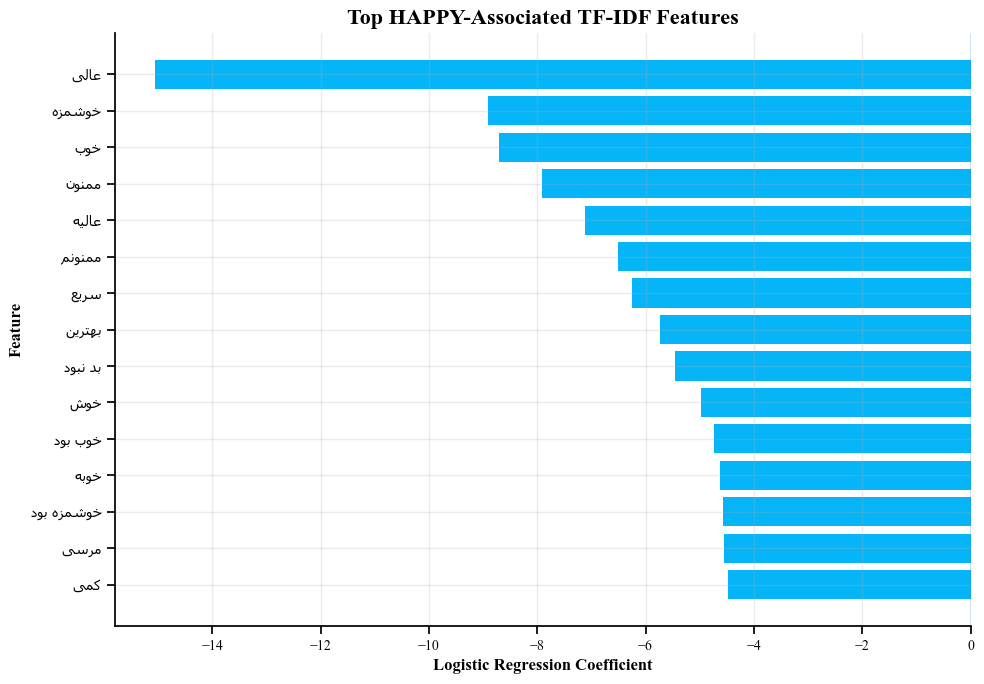

In [140]:
plt.figure(figsize=(10, 7))

plt.barh(
    happy_features,
    top_happy_features["coefficient"],
    color= PRIMARY_COLOR
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Top HAPPY-Associated TF-IDF Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Logistic Regression Coefficient",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.xticks(fontsize=10)
plt.yticks(
    fontsize=11,
    fontproperties=persian_font
)

plt.tight_layout()
plt.show()

In [141]:
sad_features = [
    reshape_persian_text(feature)
    for feature in top_sad_features["feature"]
]

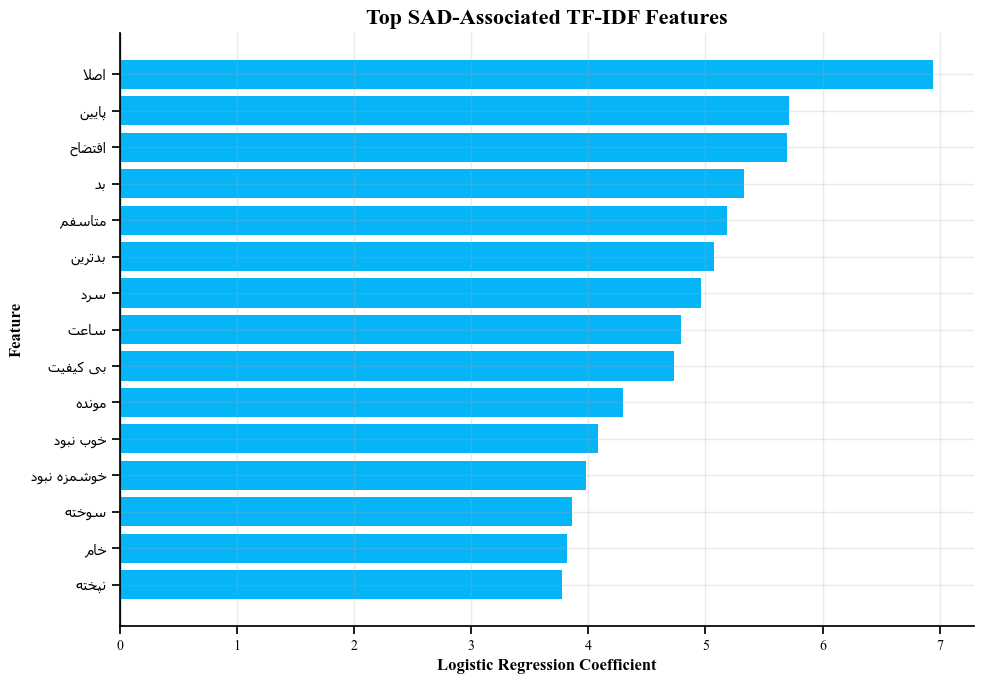

In [142]:
plt.figure(figsize=(10, 7))

plt.barh(
    sad_features,
    top_sad_features["coefficient"],
    color= PRIMARY_COLOR
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Top SAD-Associated TF-IDF Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Logistic Regression Coefficient",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.xticks(fontsize=10)
plt.yticks(
    fontsize=11,
    fontproperties=persian_font
)

plt.tight_layout()
plt.show()

### Contrastive & Sentiment-Shift Expressions

Certain discourse expressions can indicate contrast, qualification, or a potential shift in sentiment within a review.

Examples include expressions such as "ولی", "اما", "با این حال", and "متاسفانه".

This analysis examines their occurrence, sentiment distribution, and relationship with model errors. The goal is not to assume that these expressions determine sentiment, but to investigate whether they are associated with more context-dependent sentiment patterns or classification errors.

In [143]:
contrastive_expressions = [
    "ولی",
    "اما",
    "با این حال",
    "متاسفانه",
    "اگرچه",
    "هرچند"
]

In [144]:
contrastive_analysis = []

for expression in contrastive_expressions:
    mask = error_analysis_df["processed_comment"].str.contains(
        expression,
        regex=False,
        na=False
    )

    subset = error_analysis_df[mask]

    total_reviews = len(subset)
    happy_reviews = (subset["label"] == "HAPPY").sum()
    sad_reviews = (subset["label"] == "SAD").sum()
    errors = subset["is_error"].sum()

    if total_reviews > 0:
        happy_percentage = happy_reviews / total_reviews * 100
        sad_percentage = sad_reviews / total_reviews * 100
        error_rate = errors / total_reviews * 100
    else:
        happy_percentage = 0
        sad_percentage = 0
        error_rate = 0

    contrastive_analysis.append({
        "expression": expression,
        "total_reviews": total_reviews,
        "happy_reviews": happy_reviews,
        "sad_reviews": sad_reviews,
        "happy_percentage": happy_percentage,
        "sad_percentage": sad_percentage,
        "errors": errors,
        "error_rate": error_rate
    })

contrastive_analysis_df = pd.DataFrame(contrastive_analysis)

contrastive_analysis_df

,expression,total_reviews,happy_reviews,sad_reviews,happy_percentage,sad_percentage,errors,error_rate
0,ولی,1465,753,712,51.399317,48.600683,280,19.112628
1,اما,522,276,246,52.873563,47.126437,101,19.348659
2,با این حال,6,1,5,16.666667,83.333333,0,0.000000
3,متاسفانه,382,110,272,28.795812,71.204188,76,19.895288
4,اگرچه,0,0,0,0.000000,0.000000,0,0.000000
5,هرچند,8,4,4,50.000000,50.000000,3,37.500000


In [145]:
overall_error_rate = (
    error_analysis_df["is_error"].mean() * 100
)

overall_happy_percentage = (
    (error_analysis_df["label"] == "HAPPY").mean() * 100
)

overall_sad_percentage = (
    (error_analysis_df["label"] == "SAD").mean() * 100
)

print(f"Overall HAPPY percentage: {overall_happy_percentage:.2f}%")
print(f"Overall SAD percentage: {overall_sad_percentage:.2f}%")
print(f"Overall error rate: {overall_error_rate:.2f}%")

Overall HAPPY percentage: 50.29%
Overall SAD percentage: 49.71%
Overall error rate: 13.79%


In [146]:
contrastive_plot_df = contrastive_analysis_df[
    [
        "expression",
        "happy_percentage",
        "sad_percentage"
    ]
].copy()

contrastive_plot_df

,expression,happy_percentage,sad_percentage
0,ولی,51.399317,48.600683
1,اما,52.873563,47.126437
2,با این حال,16.666667,83.333333
3,متاسفانه,28.795812,71.204188
4,اگرچه,0.000000,0.000000
5,هرچند,50.000000,50.000000


In [147]:
MIN_REVIEWS = 30

reliable_contrastive_df = (
    contrastive_analysis_df[
        contrastive_analysis_df["total_reviews"] >= MIN_REVIEWS
    ]
    .copy()
    .sort_values("error_rate", ascending=False)
)

reliable_contrastive_df

,expression,total_reviews,happy_reviews,sad_reviews,happy_percentage,sad_percentage,errors,error_rate
3,متاسفانه,382,110,272,28.795812,71.204188,76,19.895288
1,اما,522,276,246,52.873563,47.126437,101,19.348659
0,ولی,1465,753,712,51.399317,48.600683,280,19.112628


In [148]:
reliable_contrastive_df["error_rate_difference"] = (
    reliable_contrastive_df["error_rate"]
    - overall_error_rate
)

reliable_contrastive_df

,expression,total_reviews,happy_reviews,sad_reviews,happy_percentage,sad_percentage,errors,error_rate,error_rate_difference
3,متاسفانه,382,110,272,28.795812,71.204188,76,19.895288,6.108391
1,اما,522,276,246,52.873563,47.126437,101,19.348659,5.561762
0,ولی,1465,753,712,51.399317,48.600683,280,19.112628,5.325731


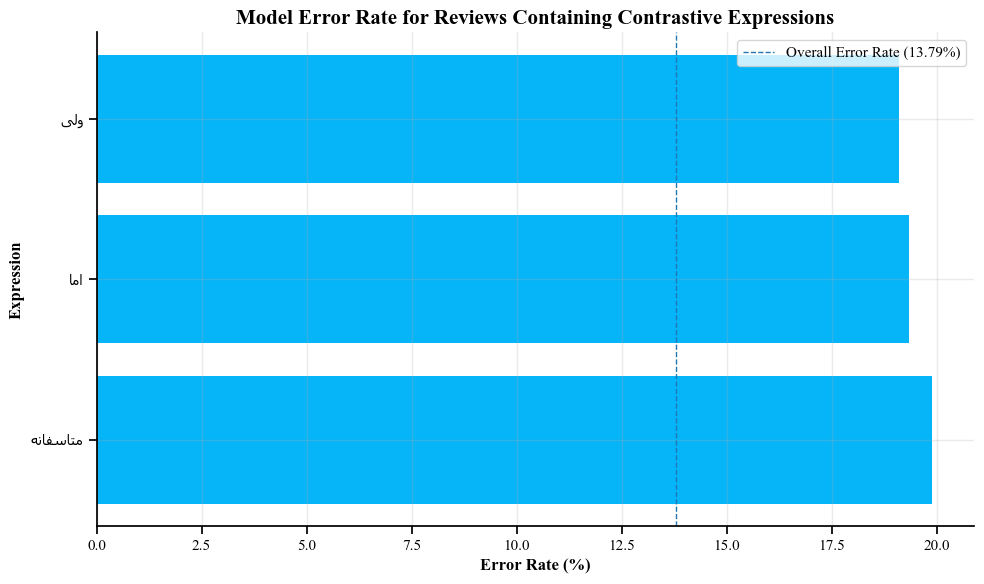

In [149]:
plt.figure(figsize=(10, 6))

plt.barh(
    reliable_contrastive_df["expression"].apply(
        reshape_persian_text
    ),
    reliable_contrastive_df["error_rate"],
    color= PRIMARY_COLOR
)

plt.axvline(
    overall_error_rate,
    linewidth=1,
    linestyle="--",
    label=f"Overall Error Rate ({overall_error_rate:.2f}%)"
)

plt.title(
    "Model Error Rate for Reviews Containing Contrastive Expressions",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Error Rate (%)",
    fontsize=12
)

plt.ylabel(
    "Expression",
    fontsize=12
)

plt.yticks(
    fontsize=11,
    fontproperties=persian_font
)

plt.legend()

plt.tight_layout()
plt.show()

In [150]:
reliable_sentiment_df = (
    reliable_contrastive_df[
        [
            "expression",
            "happy_percentage",
            "sad_percentage"
        ]
    ]
    .copy()
)

reliable_sentiment_df

,expression,happy_percentage,sad_percentage
3,متاسفانه,28.795812,71.204188
1,اما,52.873563,47.126437
0,ولی,51.399317,48.600683


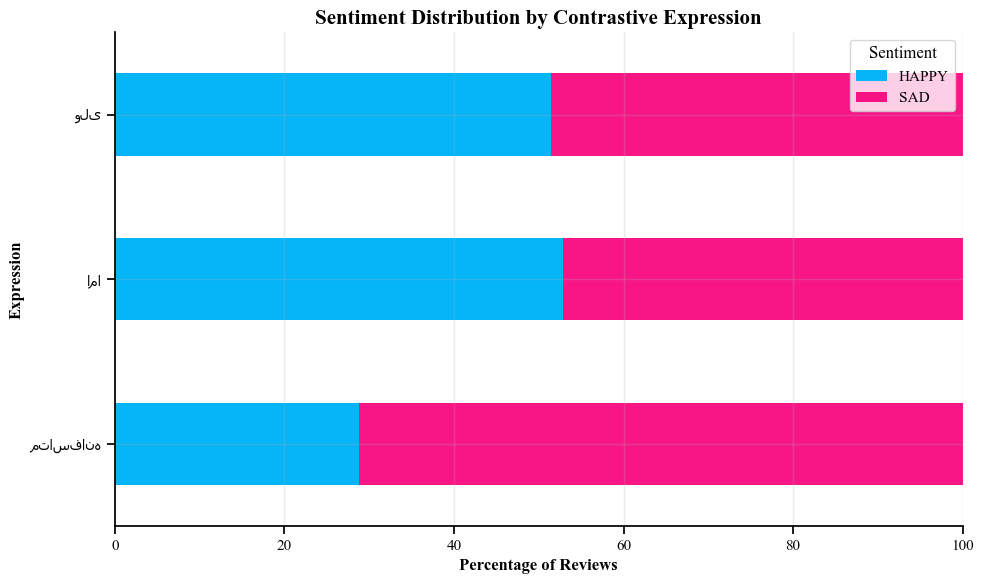

In [151]:
plot_sentiment_df = reliable_sentiment_df.set_index(
    "expression"
)[
    ["happy_percentage", "sad_percentage"]
].copy()

plot_sentiment_df.columns = [
    "HAPPY",
    "SAD"
]

ax = plot_sentiment_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    color=[PRIMARY_COLOR, SECONDARY_COLOR]
)

ax.set_title(
    "Sentiment Distribution by Contrastive Expression",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Percentage of Reviews",
    fontsize=12
)

ax.set_ylabel(
    "Expression",
    fontsize=12
)

ax.set_xlim(0, 100)

ax.legend(
    title="Sentiment"
)

plt.yticks(
    fontsize=11,
    fontproperties=persian_font
)

plt.tight_layout()
plt.show()

###  High-Confidence Errors with Contrastive Expressions

To better understand why reviews containing contrastive or negative discourse expressions are more difficult to classify, high-confidence prediction errors are examined.

The analysis focuses on reviews containing "ولی", "اما", or "متاسفانه" and identifies cases where the model made an incorrect prediction with high confidence.

These examples are used to investigate contextual sentiment, mixed sentiment, and possible limitations of the TF-IDF-based classifier.

In [152]:
target_expressions = [
    "ولی",
    "اما",
    "متاسفانه"
]

contrastive_errors_df = error_analysis_df[
    error_analysis_df["error_type"] != "Correct"
].copy()

contrastive_errors_df = contrastive_errors_df[
    contrastive_errors_df["processed_comment"].apply(
        lambda text: any(
            expression in text
            for expression in target_expressions
        )
    )
].copy()

contrastive_errors_df["prediction_confidence"] = (
    contrastive_errors_df["sad_probability"].where(
        contrastive_errors_df["predicted_label"] == "SAD",
        1 - contrastive_errors_df["sad_probability"]
    )
)

high_confidence_contrastive_errors = (
    contrastive_errors_df[
        contrastive_errors_df["prediction_confidence"] >= 0.90
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .copy()
)

print(
    f"Contrastive-expression errors: "
    f"{len(contrastive_errors_df):,}"
)

print(
    f"High-confidence errors (≥90%): "
    f"{len(high_confidence_contrastive_errors):,}"
)

Contrastive-expression errors: 413
High-confidence errors (≥90%): 31


In [153]:
contrastive_errors_df = contrastive_errors_df[
    contrastive_errors_df["processed_comment"].apply(
        lambda text: any(
            expression in text
            for expression in target_expressions
        )
    )
].copy()

In [154]:
contrastive_errors_df["prediction_confidence"] = (
    contrastive_errors_df["sad_probability"].where(
        contrastive_errors_df["predicted_label"] == "SAD",
        1 - contrastive_errors_df["sad_probability"]
    )
)

In [155]:
contrastive_error_examples = (
    high_confidence_contrastive_errors[
        [
            "comment",
            "label",
            "predicted_label",
            "sad_probability",
            "prediction_confidence",
            "error_type"
        ]
    ]
    .head(15)
    .copy()
)

contrastive_error_examples

,comment,label,predicted_label,sad_probability,prediction_confidence,error_type
5282,غذا عالی بود اما قیمتش گران بود,SAD,HAPPY,0.017114,0.982886,False Negative
2489,غذا سریع رسید و داغ بود موادش کیفیت خوبی داشت ...,SAD,HAPPY,0.035464,0.964536,False Negative
5347,سرعت ارسال عالی بود ولی گوشتهاش نپخته بود,SAD,HAPPY,0.040584,0.959416,False Negative
3645,پیتزای پپرونی عالی بود اگر فلفل هالوپ-ن- هم اض...,SAD,HAPPY,0.041432,0.958568,False Negative
6286,به جای تردیلا پنیری متاسفانه تنوری فرستادن که ...,HAPPY,SAD,0.954759,0.954759,False Positive
2055,پیک رستوران بسیار بی ادب و بی مسئولیت بودند …م...,HAPPY,SAD,0.950204,0.950204,False Positive
6263,خیلی خوشمزه و خوب بود و تایم رسیدنش هم عالی! ف...,SAD,HAPPY,0.050650,0.949350,False Negative
37,یه پیتزای معمولی بود چیز خاصی نبود که دفعه بعد...,HAPPY,SAD,0.947221,0.947221,False Positive
5533,یعنی امان امان ازین ساندویچ من! اولا که من ۲تا...,HAPPY,SAD,0.945773,0.945773,False Positive
6848,فقط یه کم سیب زمینی‌ها ریخته بودند بیرون. ولی ...,SAD,HAPPY,0.054464,0.945536,False Negative


In [156]:
expression_error_counts = []

for expression in target_expressions:
    mask = high_confidence_contrastive_errors[
        "processed_comment"
    ].str.contains(
        expression,
        regex=False,
        na=False
    )

    expression_error_counts.append({
        "expression": expression,
        "high_confidence_errors": mask.sum()
    })

expression_error_counts_df = pd.DataFrame(
    expression_error_counts
)

expression_error_counts_df

,expression,high_confidence_errors
0,ولی,18
1,اما,6
2,متاسفانه,8


In [157]:
contrastive_error_type_counts = (
    high_confidence_contrastive_errors[
        "error_type"
    ]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

contrastive_error_type_counts

,error_type,count
0,False Positive,20
1,False Negative,11


###  Error Examples by Error Type

False Positive and False Negative errors are examined separately to identify different patterns of model failure.

False Positives represent HAPPY reviews incorrectly classified as SAD, while False Negatives represent SAD reviews incorrectly classified as HAPPY.

Separating these error types helps distinguish cases where the model overestimates negative sentiment from cases where it fails to capture negative sentiment in context.

In [158]:
high_confidence_fp = (
    high_confidence_contrastive_errors[
        high_confidence_contrastive_errors["error_type"] == "False Positive"
    ]
    [
        [
            "comment",
            "label",
            "predicted_label",
            "sad_probability",
            "prediction_confidence"
        ]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .copy()
)

high_confidence_fp

,comment,label,predicted_label,sad_probability,prediction_confidence
6286,به جای تردیلا پنیری متاسفانه تنوری فرستادن که ...,HAPPY,SAD,0.954759,0.954759
2055,پیک رستوران بسیار بی ادب و بی مسئولیت بودند …م...,HAPPY,SAD,0.950204,0.950204
37,یه پیتزای معمولی بود چیز خاصی نبود که دفعه بعد...,HAPPY,SAD,0.947221,0.947221
5533,یعنی امان امان ازین ساندویچ من! اولا که من ۲تا...,HAPPY,SAD,0.945773,0.945773
1191,قسمت زیر خمیر دور سوسیس کاملا نپخته و خمیر بود...,HAPPY,SAD,0.941592,0.941592
1382,متاسفانه کباب بی مزه بود …,HAPPY,SAD,0.930133,0.930133
3424,متاسفانه آب معدنی همراه سفارشات نبود. بستنی فر...,HAPPY,SAD,0.929567,0.929567
2524,متاسفانه نان ارسالی بسیار بیات و قدیمی بود … ی...,HAPPY,SAD,0.928197,0.928197
2168,متاسفانه بشدت کیفیت افت کرده قطعا استیک روی پی...,HAPPY,SAD,0.925989,0.925989
2190,من چند بار تا حالا سفارش دادم. ولی ایندفعه کیف...,HAPPY,SAD,0.921291,0.921291


In [159]:
high_confidence_fn = (
    high_confidence_contrastive_errors[
        high_confidence_contrastive_errors["error_type"] == "False Negative"
    ]
    [
        [
            "comment",
            "label",
            "predicted_label",
            "sad_probability",
            "prediction_confidence"
        ]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .copy()
)

high_confidence_fn

,comment,label,predicted_label,sad_probability,prediction_confidence
5282,غذا عالی بود اما قیمتش گران بود,SAD,HAPPY,0.017114,0.982886
2489,غذا سریع رسید و داغ بود موادش کیفیت خوبی داشت ...,SAD,HAPPY,0.035464,0.964536
5347,سرعت ارسال عالی بود ولی گوشتهاش نپخته بود,SAD,HAPPY,0.040584,0.959416
3645,پیتزای پپرونی عالی بود اگر فلفل هالوپ-ن- هم اض...,SAD,HAPPY,0.041432,0.958568
6263,خیلی خوشمزه و خوب بود و تایم رسیدنش هم عالی! ف...,SAD,HAPPY,0.050650,0.949350
6848,فقط یه کم سیب زمینی‌ها ریخته بودند بیرون. ولی ...,SAD,HAPPY,0.054464,0.945536
8204,خوشمزه بود، ولی سرد رسید,SAD,HAPPY,0.057815,0.942185
634,دیزی ریخته بود سیب زمینی هم نداشت ولی داغ و خو...,SAD,HAPPY,0.075833,0.924167
7384,خورشت خوشمزه بود ولی لوبیاش خیلی کم بود,SAD,HAPPY,0.080089,0.919911
3953,مدت زمان آوردن غذا و نحوه بسته بندی خوب بود ول...,SAD,HAPPY,0.080322,0.919678


###  Coefficient-Weighted Sentiment Visualization

The Logistic Regression coefficients provide an interpretable view of which TF-IDF features are associated with each sentiment class.

Positive coefficients indicate stronger association with the SAD class, while negative coefficients indicate stronger association with the HAPPY class.

To visualize these associations, the strongest sentiment-related features are represented using coefficient magnitude as their visual weight. This visualization is intended for model interpretation rather than frequency analysis.

In [160]:
TOP_N = 30

happy_features = (
    feature_importance_df[
        feature_importance_df["coefficient"] < 0
    ]
    .assign(
        weight=lambda df: df["coefficient"].abs()
    )
    .sort_values(
        "weight",
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

sad_features = (
    feature_importance_df[
        feature_importance_df["coefficient"] > 0
    ]
    .assign(
        weight=lambda df: df["coefficient"]
    )
    .sort_values(
        "weight",
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

In [161]:
print("Top HAPPY-associated features:")
display(
    happy_features[
        ["feature", "coefficient"]
    ]
)

print("\nTop SAD-associated features:")
display(
    sad_features[
        ["feature", "coefficient"]
    ]
)

Top HAPPY-associated features:


,feature,coefficient
51565,عالی,-15.049679
31682,خوشمزه,-8.914844
30416,خوب,-8.700565
62875,ممنون,-7.913057
51880,عالیه,-7.127010
62977,ممنونم,-6.517451
44531,سریع,-6.247951
18224,بهترین,-5.729829
13194,بد نبود,-5.454700
31575,خوش,-4.972628



Top SAD-associated features:


,feature,coefficient
4767,اصلا,6.944130
78737,پایین,5.713468
5506,افتضاح,5.691479
13074,بد,5.329926
59131,متاسفم,5.186798
13271,بدترین,5.070685
44084,سرد,4.957906
42786,ساعت,4.792000
21404,بی کیفیت,4.728490
64885,مونده,4.294944


###  Qualitative Error Analysis

The qualitative analysis of model errors revealed several recurring patterns.

First, reviews containing contrastive or discourse expressions such as "ولی", "اما", and "متاسفانه" showed higher error rates than the overall validation error rate. This suggests that contextual sentiment and contrastive sentence structures can be challenging for the TF-IDF-based classifier.

Second, several high-confidence False Positives and False Negatives contained sentiment cues that were not fully aligned with the final sentiment of the review. Since TF-IDF represents text primarily through lexical features and Logistic Regression assigns independent weights to these features, the model may rely strongly on individual positive or negative terms without fully modeling their contextual relationship.

Third, some high-confidence errors appeared inconsistent with their dataset labels. These cases may indicate potential annotation inconsistency or ambiguity in the underlying reviews. However, they were not manually relabeled because there was no independent ground-truth source available.

The analysis also showed that review length was not a major driver of classification errors. Error rates remained relatively close across short, medium, long, and very long reviews.

Overall, the main limitations identified through error analysis are related to contextual sentiment, contrastive structures, mixed sentiment, and potential annotation inconsistency rather than text length alone.

##  Error Analysis Summary

The error analysis provided additional insight into the behavior and limitations of the selected Logistic Regression model.

The main findings were:

- Review length did not appear to be a major driver of classification errors. Error rates remained relatively close across different review-length groups.
- Reviews containing contrastive or discourse expressions such as "ولی", "اما", and "متاسفانه" showed higher error rates than the overall validation error rate.
- High-confidence False Positives and False Negatives revealed cases where individual lexical sentiment cues did not fully represent the overall sentiment of the review.
- Several errors suggested that the model can struggle with contrastive structures, mixed sentiment, and contextual sentiment.
- Some high-confidence disagreements appeared potentially inconsistent with the assigned dataset labels. These cases were treated as possible annotation inconsistency rather than definitively mislabeled samples.

Overall, the analysis indicates that the main limitations of the TF-IDF + Logistic Regression approach are related to contextual understanding and sentence-level sentiment composition rather than review length.

These findings also provide a practical explanation for why a lexical linear model can achieve strong performance while still making confident errors on context-dependent reviews.

##  Exporting the Final Model Artifacts

Before deployment, the final trained Logistic Regression model and TF-IDF vectorizer are exported as reusable artifacts.

The API will load these artifacts directly and will not depend on the Jupyter Notebook for prediction.

In [162]:
from pathlib import Path
import joblib

ARTIFACT_DIR = Path("models/sentiment_api")
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_model,
    ARTIFACT_DIR / "sentiment_model.joblib"
)

joblib.dump(
    final_tfidf_vectorizer,
    ARTIFACT_DIR / "tfidf_vectorizer.joblib"
)

print("Model artifacts exported successfully.")
print(f"Artifact directory: {ARTIFACT_DIR}")

Model artifacts exported successfully.
Artifact directory: models\sentiment_api


#  Project Conclusion

This project developed an end-to-end Persian customer review sentiment analysis pipeline using real-world food delivery reviews.

The workflow covered:

- Dataset validation and exploratory analysis
- Persian-specific text normalization
- Duplicate and cross-split leakage detection
- TF-IDF feature extraction
- Evaluation of multiple classical machine learning approaches
- Transformer feasibility assessment
- Model comparison and selection
- High-confidence error analysis
- Contextual and contrastive-expression analysis
- Final evaluation on an isolated test set
- A reusable inference pipeline for unseen reviews

The final model, **TF-IDF + Logistic Regression**, achieved a Test Macro F1 of **0.8604** and an Accuracy of **0.8607**.

The model was selected based on its overall validation performance, computational efficiency, interpretability, and simplicity relative to the other evaluated approaches.

The final inference pipeline preserves the same preprocessing and feature transformation logic used during model development. The trained model and TF-IDF vectorizer are now ready to be exported and integrated into a lightweight API for real-time sentiment prediction.